<a href="https://colab.research.google.com/github/LinhChi2808/Predicting_Customer_Churn/blob/main/DOAN_NHOM3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ĐỒ ÁN - PREDICTING CUSTOMER CHURN**



**Giáo viên hướng dẫn:** ThS.Dương Phi Long

**Môn học:** Phân tích dữ liệu kinh doanh - IS403.Q11

**Nhóm 3**

| Họ và tên | MSSV    |
|-----------|---------|
|Trần Linh Chi|22520154|
|Phùng Khánh Hoàng|22520476|
|Nguyễn Hiếu Nghĩa|22520948|
|Huỳnh Quốc Thiên Ân|22520015|
|Đặng Việt Hoàng|22520458|


**Đề tài:** PREDICTING CUSTOMER CHURN IN TELECOM (FIBER OPTIC INTERNET) USING CUSTOMER BEHAVIORAL DATA

**Dataset:** https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset/data



---



# Import các thư viện cần thiết

In [ ]:
!pip install optuna
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.8 MB/s eta 0:00:00


In [ ]:

from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.svm import LinearSVC
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance

In [ ]:
import warnings
warnings.filterwarnings("ignore")



---



# Đọc file dữ liệu

In [ ]:
# Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Đường dẫn file
path_train = '/content/drive/MyDrive/UIT/PTDLKD/DOAN/customer_churn_dataset-training-master.csv'
path_test = '/content/drive/MyDrive/UIT/PTDLKD/DOAN/customer_churn_dataset-testing-master.csv'

df_train = pd.read_csv(path_train)
df_test = pd.read_csv(path_test)

# 3. Hiển thị thử 5 dòng đầu
print("Dữ liệu Training:")
display(df_train.head())

print("Dữ liệu Testing:")
display(df_test.head())

Mounted at /content/drive
Dữ liệu Training:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


Dữ liệu Testing:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0




---



# Kiểm tra dữ liệu


## Giá trị bị thiếu (Missing Values)

In [ ]:
#Hàm kiểm tra Missing values
def check_missing_values(df, dataset_name="Dataset"):
    print(f"--- Kiểm tra giá trị thiếu cho: {dataset_name} ---")

    # Tính tổng số giá trị thiếu cho mỗi cột
    missing_count = df.isnull().sum()

    # Lọc ra các cột thực sự có dữ liệu thiếu để hiển thị cho gọn
    missing_cols = missing_count[missing_count > 0]

    if missing_cols.empty:
        print("Không có giá trị thiếu nào trong tập dữ liệu này.")
    else:
        print("Phát hiện các cột có giá trị thiếu:")
        # Tính phần trăm thiếu để dễ hình dung mức độ nghiêm trọng
        missing_percent = (missing_cols / len(df)) * 100

        # Tạo bảng kết quả đẹp mắt
        missing_report = pd.DataFrame({
            'Số lượng thiếu': missing_cols,
            'Tỷ lệ thiếu (%)': missing_percent
        })
        print(missing_report.sort_values(by='Số lượng thiếu', ascending=False))
    print("-" * 50 + "\n")

# --- Gọi hàm để kiểm tra ---
check_missing_values(df_train, "Tập Huấn Luyện (Training)")
check_missing_values(df_test, "Tập Kiểm Tra (Testing)")

--- Kiểm tra giá trị thiếu cho: Tập Huấn Luyện (Training) ---
Phát hiện các cột có giá trị thiếu:
                   Số lượng thiếu  Tỷ lệ thiếu (%)
CustomerID                      1         0.000227
Age                             1         0.000227
Gender                          1         0.000227
Tenure                          1         0.000227
Usage Frequency                 1         0.000227
Support Calls                   1         0.000227
Payment Delay                   1         0.000227
Subscription Type               1         0.000227
Contract Length                 1         0.000227
Total Spend                     1         0.000227
Last Interaction                1         0.000227
Churn                           1         0.000227
--------------------------------------------------

--- Kiểm tra giá trị thiếu cho: Tập Kiểm Tra (Testing) ---
Không có giá trị thiếu nào trong tập dữ liệu này.
--------------------------------------------------



=> Có 1 dòng bị thiếu hết tất cả thuộc tính ở tập huấn luyện

=> Xóa bỏ dòng đó

## Dòng trùng lặp (Duplicates)



In [ ]:
# Kiểm tra trùng lặp
print(f"Số dòng trùng lặp trong file Training: {df_train.duplicated().sum()}")
print(f"Số dòng trùng lặp trong file Testing: {df_test.duplicated().sum()}")

# Kết luận
if df_train.duplicated().sum() == 0 and df_test.duplicated().sum() == 0:
    print("\n✅ Kết luận: Cả hai tập dữ liệu đều không có dòng trùng lặp. Dữ liệu sạch.")
else:
    print("\n⚠️ Cảnh báo: Có dòng trùng lặp cần xử lý.")

Số dòng trùng lặp trong file Training: 0
Số dòng trùng lặp trong file Testing: 0

✅ Kết luận: Cả hai tập dữ liệu đều không có dòng trùng lặp. Dữ liệu sạch.


## Tên các thuộc tính

In [ ]:
list(df_train.columns)
list(df_test.columns)

['CustomerID',
 'Age',
 'Gender',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Subscription Type',
 'Contract Length',
 'Total Spend',
 'Last Interaction',
 'Churn']

=> Cần chuẩn hóa tên bằng cách thay khoảng cách bằng dấu _

## Kiểu dữ liệu (Data Types)

In [ ]:
# 2. Kiểm tra kiểu dữ liệu bằng hàm .info()
# Hàm này cho biết: Tên cột, Số lượng dòng không rỗng (Non-Null), và Kiểu dữ liệu (Dtype)
print("--- THÔNG TIN TẬP TRAINING ---")
df_train.info()

print("\n--- THÔNG TIN TẬP TESTING ---")
df_test.info()


--- THÔNG TIN TẬP TRAINING ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB

--- THÔNG TIN TẬP TESTING ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns

- Hai file có kiểu dữ liệu khác nhau: File Training là kiểu float, File Testing là kiểu int

=> Đồng bộ kiểu dữ liệu: Chuyển tất cả về float (vì float có thể chứa được int, nhưng int thì sẽ làm mất phần thập phân của float)



---



# Data Cleaning - Tiền xử lý thô

In [ ]:
df_train_cleaned = df_train.copy()
df_test_cleaned = df_test.copy()

## Xử lý giá trị thiếu (Missing values)

In [ ]:
# Xử lý giá trị thiếu
# Quyết định: Xóa dòng thiếu vì số lượng rất nhỏ (chỉ 1 dòng / 440k dòng)
df_train_cleaned.dropna(inplace=True)

# Xác nhận kết quả
print("Đã xử lý xong giá trị thiếu.")
print(f"Kích thước tập Train hiện tại: {df_train_cleaned.shape}")

Đã xử lý xong giá trị thiếu.
Kích thước tập Train hiện tại: (440832, 12)


## Chuẩn hóa tên Thuộc tính

In [ ]:
# Hàm chuẩn hóa tên cột
def standardize_columns(df):
    # str.strip(): Xóa khoảng trắng thừa ở đầu/cuối
    # str.replace(' ', '_'): Thay khoảng trắng ở giữa bằng dấu _
    df.columns = df.columns.str.strip().str.replace(' ', '_')
    return df

# Áp dụng cho cả 2 tập dữ liệu
df_train_cleaned = standardize_columns(df_train_cleaned)
df_test_cleaned = standardize_columns(df_test_cleaned)

# Kiểm tra kết quả
print("Danh sách tên cột Training sau khi chuẩn hóa:")
print(df_train_cleaned.columns.tolist())
print("Danh sách tên cột Testing sau khi chuẩn hóa:")
print(df_test_cleaned.columns.tolist())

Danh sách tên cột Training sau khi chuẩn hóa:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Delay', 'Subscription_Type', 'Contract_Length', 'Total_Spend', 'Last_Interaction', 'Churn']
Danh sách tên cột Testing sau khi chuẩn hóa:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Delay', 'Subscription_Type', 'Contract_Length', 'Total_Spend', 'Last_Interaction', 'Churn']


## Đồng bộ kiểu dữ liệu

In [ ]:
# --- ĐỒNG BỘ KIỂU DỮ LIỆU ---

# Danh sách các cột số cần đồng bộ về float
num_cols = ['CustomerID', 'Age', 'Tenure', 'Usage_Frequency', 'Support_Calls',
            'Payment_Delay', 'Total_Spend', 'Last_Interaction', 'Churn']

# Chuyển đổi cả 2 tập về float64 để thống nhất
for col in num_cols:
    df_train_cleaned[col] = df_train_cleaned[col].astype(float)
    df_test_cleaned[col] = df_test_cleaned[col].astype(float)

# Kiểm tra tổng thể lại một lần nữa
print("\nĐã đồng bộ toàn bộ dữ liệu số về float64.")
print("\n--- Kiểu dữ liệu train ---")
print(df_train_cleaned.dtypes)
print("\n--- Kiểu dữ liệu test ---")
print(df_test_cleaned.dtypes)




Đã đồng bộ toàn bộ dữ liệu số về float64.

--- Kiểu dữ liệu train ---
CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage_Frequency      float64
Support_Calls        float64
Payment_Delay        float64
Subscription_Type     object
Contract_Length       object
Total_Spend          float64
Last_Interaction     float64
Churn                float64
dtype: object

--- Kiểu dữ liệu test ---
CustomerID           float64
Age                  float64
Gender                object
Tenure               float64
Usage_Frequency      float64
Support_Calls        float64
Payment_Delay        float64
Subscription_Type     object
Contract_Length       object
Total_Spend          float64
Last_Interaction     float64
Churn                float64
dtype: object


## Loại bỏ các thuộc tính không cần thiết

Xóa cột ID

In [ ]:
# Danh sách các cột ID cần xóa
cols_to_drop = ['CustomerID']

# Thực hiện xóa
df_train_cleaned = df_train_cleaned.drop(columns=cols_to_drop, errors='ignore')
df_test_cleaned = df_test_cleaned.drop(columns=cols_to_drop, errors='ignore')

print("✅ Đã xóa các cột ID thành công!")

# Kiểm tra lại dữ liệu sau khi xóa
print("--- Dữ liệu train ---")
print(f"Kích thước dữ liệu hiện tại: {df_train_cleaned.shape}") # (Số dòng, Số cột)

# Hiển thị 5 dòng đầu để kiểm tra lại dữ liệu sau khi xóa các cột
print("\n--- Dữ liệu sau khi đã xóa các cột không cần thiết ---")
display(df_train_cleaned.head())

print("\n--- Dữ liệu test ---")
print(f"Kích thước dữ liệu hiện tại: {df_test_cleaned.shape}") # (Số dòng, Số cột)

# Hiển thị 5 dòng đầu để kiểm tra lại dữ liệu sau khi xóa các cột
print("\n--- Dữ liệu sau khi đã xóa các cột không cần thiết ---")
display(df_test_cleaned.head())

✅ Đã xóa các cột ID thành công!
--- Dữ liệu train ---
Kích thước dữ liệu hiện tại: (440832, 11)

--- Dữ liệu sau khi đã xóa các cột không cần thiết ---


,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Subscription_Type,Contract_Length,Total_Spend,Last_Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0



--- Dữ liệu test ---
Kích thước dữ liệu hiện tại: (64374, 11)

--- Dữ liệu sau khi đã xóa các cột không cần thiết ---


,Age,Gender,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Subscription_Type,Contract_Length,Total_Spend,Last_Interaction,Churn
0,22.0,Female,25.0,14.0,4.0,27.0,Basic,Monthly,598.0,9.0,1.0
1,41.0,Female,28.0,28.0,7.0,13.0,Standard,Monthly,584.0,20.0,0.0
2,47.0,Male,27.0,10.0,2.0,29.0,Premium,Annual,757.0,21.0,0.0
3,35.0,Male,9.0,12.0,5.0,17.0,Premium,Quarterly,232.0,18.0,0.0
4,53.0,Female,58.0,24.0,9.0,2.0,Standard,Annual,533.0,18.0,0.0




---



# EDA - Khám phá dữ liệu

## Phân tích biến mục tiêu (Target Variable Analysis)

**Tập Training**

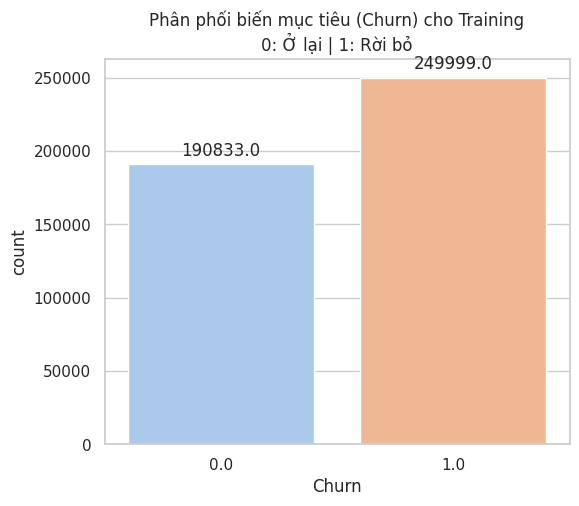


--- Tỷ lệ khách hàng (Training)---
Churn
1.0    249999
0.0    190833
Name: count, dtype: int64
Tỷ lệ Rời bỏ (1): 56.71%


In [ ]:
# Cài đặt giao diện
sns.set(style="whitegrid")

# Vẽ biểu đồ đếm số lượng Churn
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Churn', data=df_train_cleaned, palette='pastel')

# Thêm nhãn số lượng trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Phân phối biến mục tiêu (Churn) cho Training\n0: Ở lại | 1: Rời bỏ')
plt.show()

# Kiểm tra sự cân bằng của nhãn
print("\n--- Tỷ lệ khách hàng (Training)---")
print(df_train_cleaned['Churn'].value_counts())
print(f"Tỷ lệ Rời bỏ (1): {df_train_cleaned['Churn'].mean():.2%}")



- Rời bỏ (1): 56.7%

- Ở lại (0): 43.3%

Kết luận: khá cân bằng, tỷ lệ này được coi là "đủ tốt" để học mà không cần kỹ thuật cân bằng dữ liệu đặc biệt.

**Tập Testing**

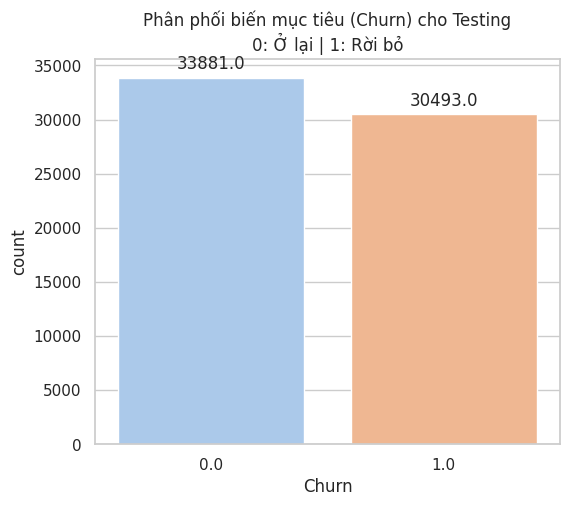


--- Tỷ lệ khách hàng (Testing)---
Churn
0.0    33881
1.0    30493
Name: count, dtype: int64
Tỷ lệ Rời bỏ (1): 47.37%


In [ ]:
# Cài đặt giao diện
sns.set(style="whitegrid")

# Vẽ biểu đồ đếm số lượng Churn
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='Churn', data=df_test_cleaned, palette='pastel')

# Thêm nhãn số lượng trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.title('Phân phối biến mục tiêu (Churn) cho Testing\n0: Ở lại | 1: Rời bỏ')
plt.show()

# Kiểm tra sự cân bằng của nhãn
print("\n--- Tỷ lệ khách hàng (Testing)---")
print(df_test_cleaned['Churn'].value_counts())
print(f"Tỷ lệ Rời bỏ (1): {df_test_cleaned['Churn'].mean():.2%}")



Có sự chênh lệch về Tỷ lệ rời bỏ đáng kể giữa tập Train và Test (khoảng 9%) => Phân phối dữ liệu có vẻ đã thay đổi.

=> Có thể gây ra giảm tỷ lệ chính xác khi dự đoán

## Phân tích đơn biến (Univariate Analysis)

### Phân tích phân phối

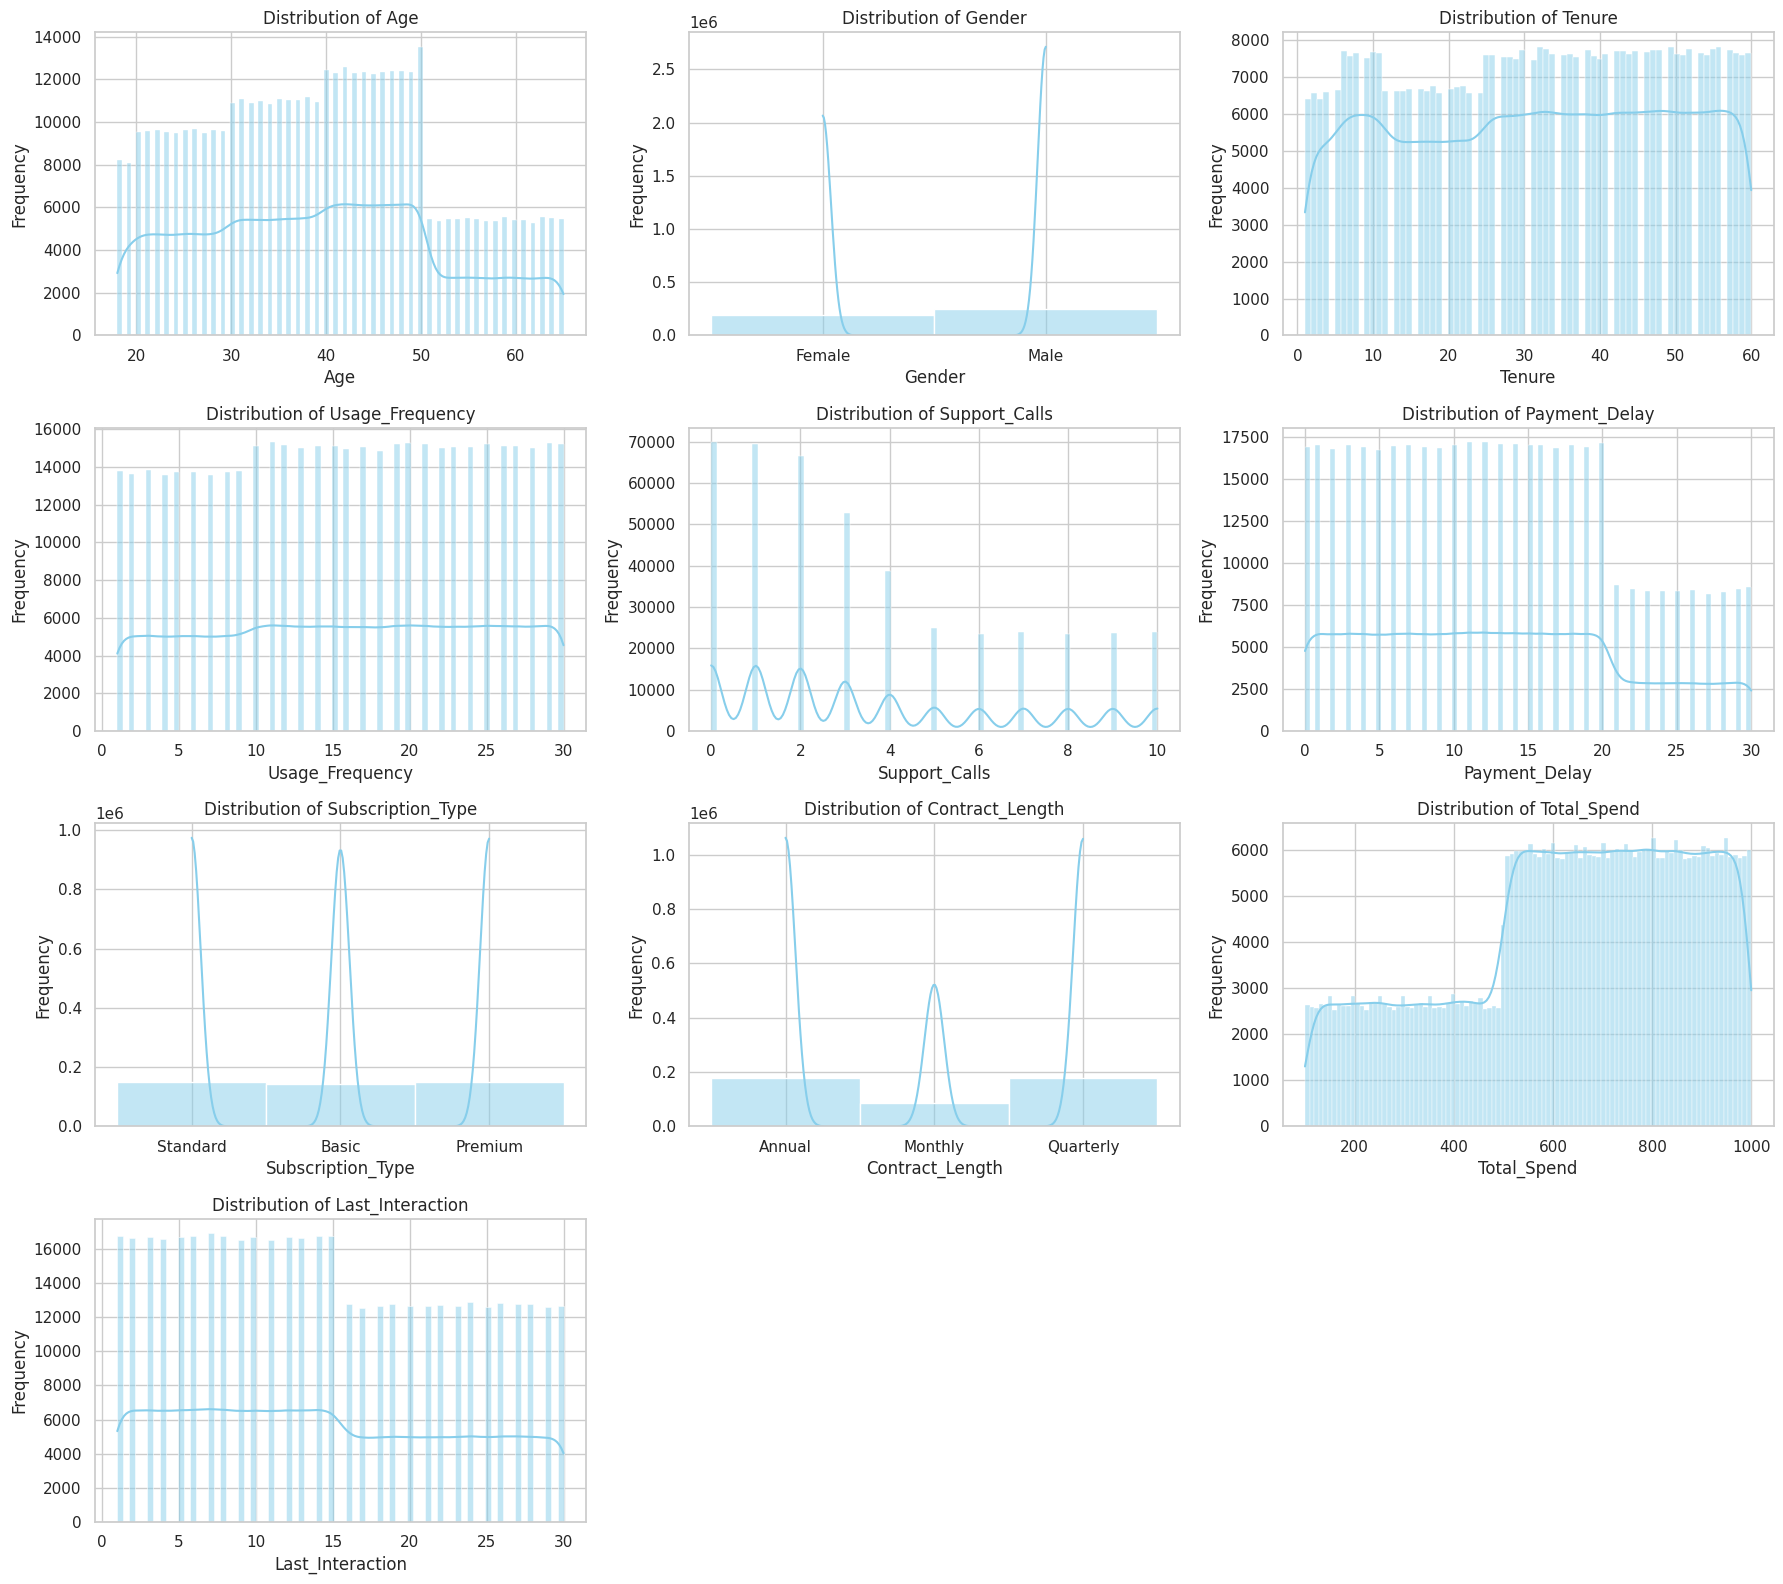

In [ ]:
# Danh sách các biến số cần phân tích
numeric_cols = ['Age', 'Gender', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Delay', 'Subscription_Type', 'Contract_Length', 'Total_Spend', 'Last_Interaction'
]

# Số lượng cột trong mỗi hàng plot
num_cols = 3
num_rows = (len(numeric_cols) + num_cols - 1) // num_cols

plt.figure(figsize=(18, num_rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.histplot(df_train_cleaned[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


### Phân tích Ngoại lai (Outliers)

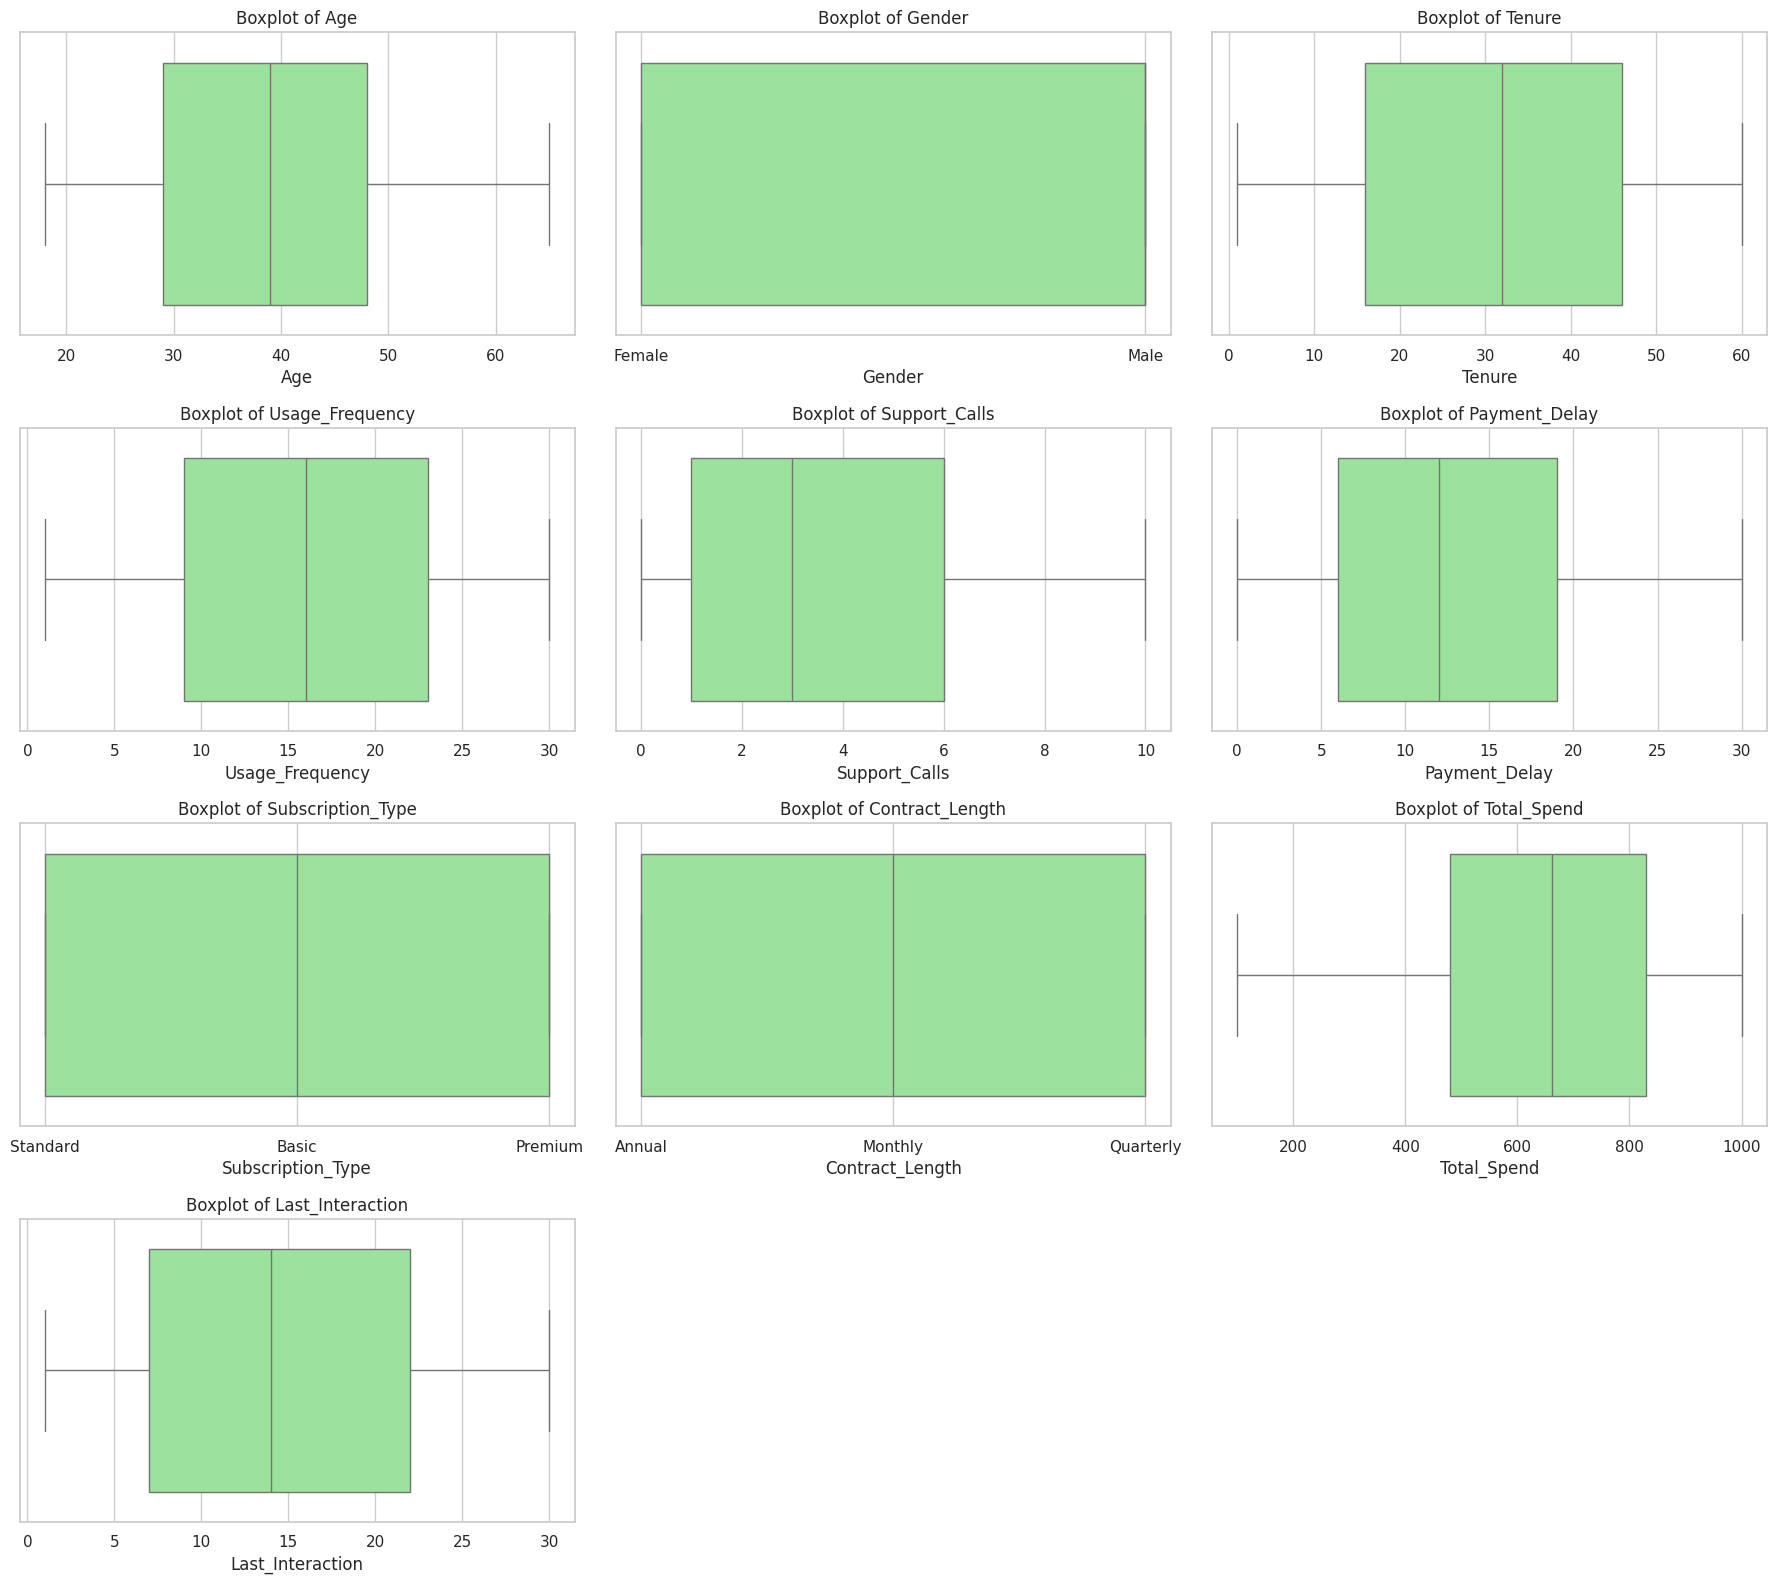

In [ ]:
plt.figure(figsize=(18, num_rows * 4))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, num_cols, i)
    sns.boxplot(x=df_train_cleaned[col], color='lightgreen')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel(col)

plt.tight_layout()
plt.show()


=> Không có giá trị ngoại lai

## Phân tích đa biến - Quan hệ giữa các biến với Churn (Bivariate Analysis)

### Quan hệ giữa Biến Định lượng và Churn (Numerical vs Churn)

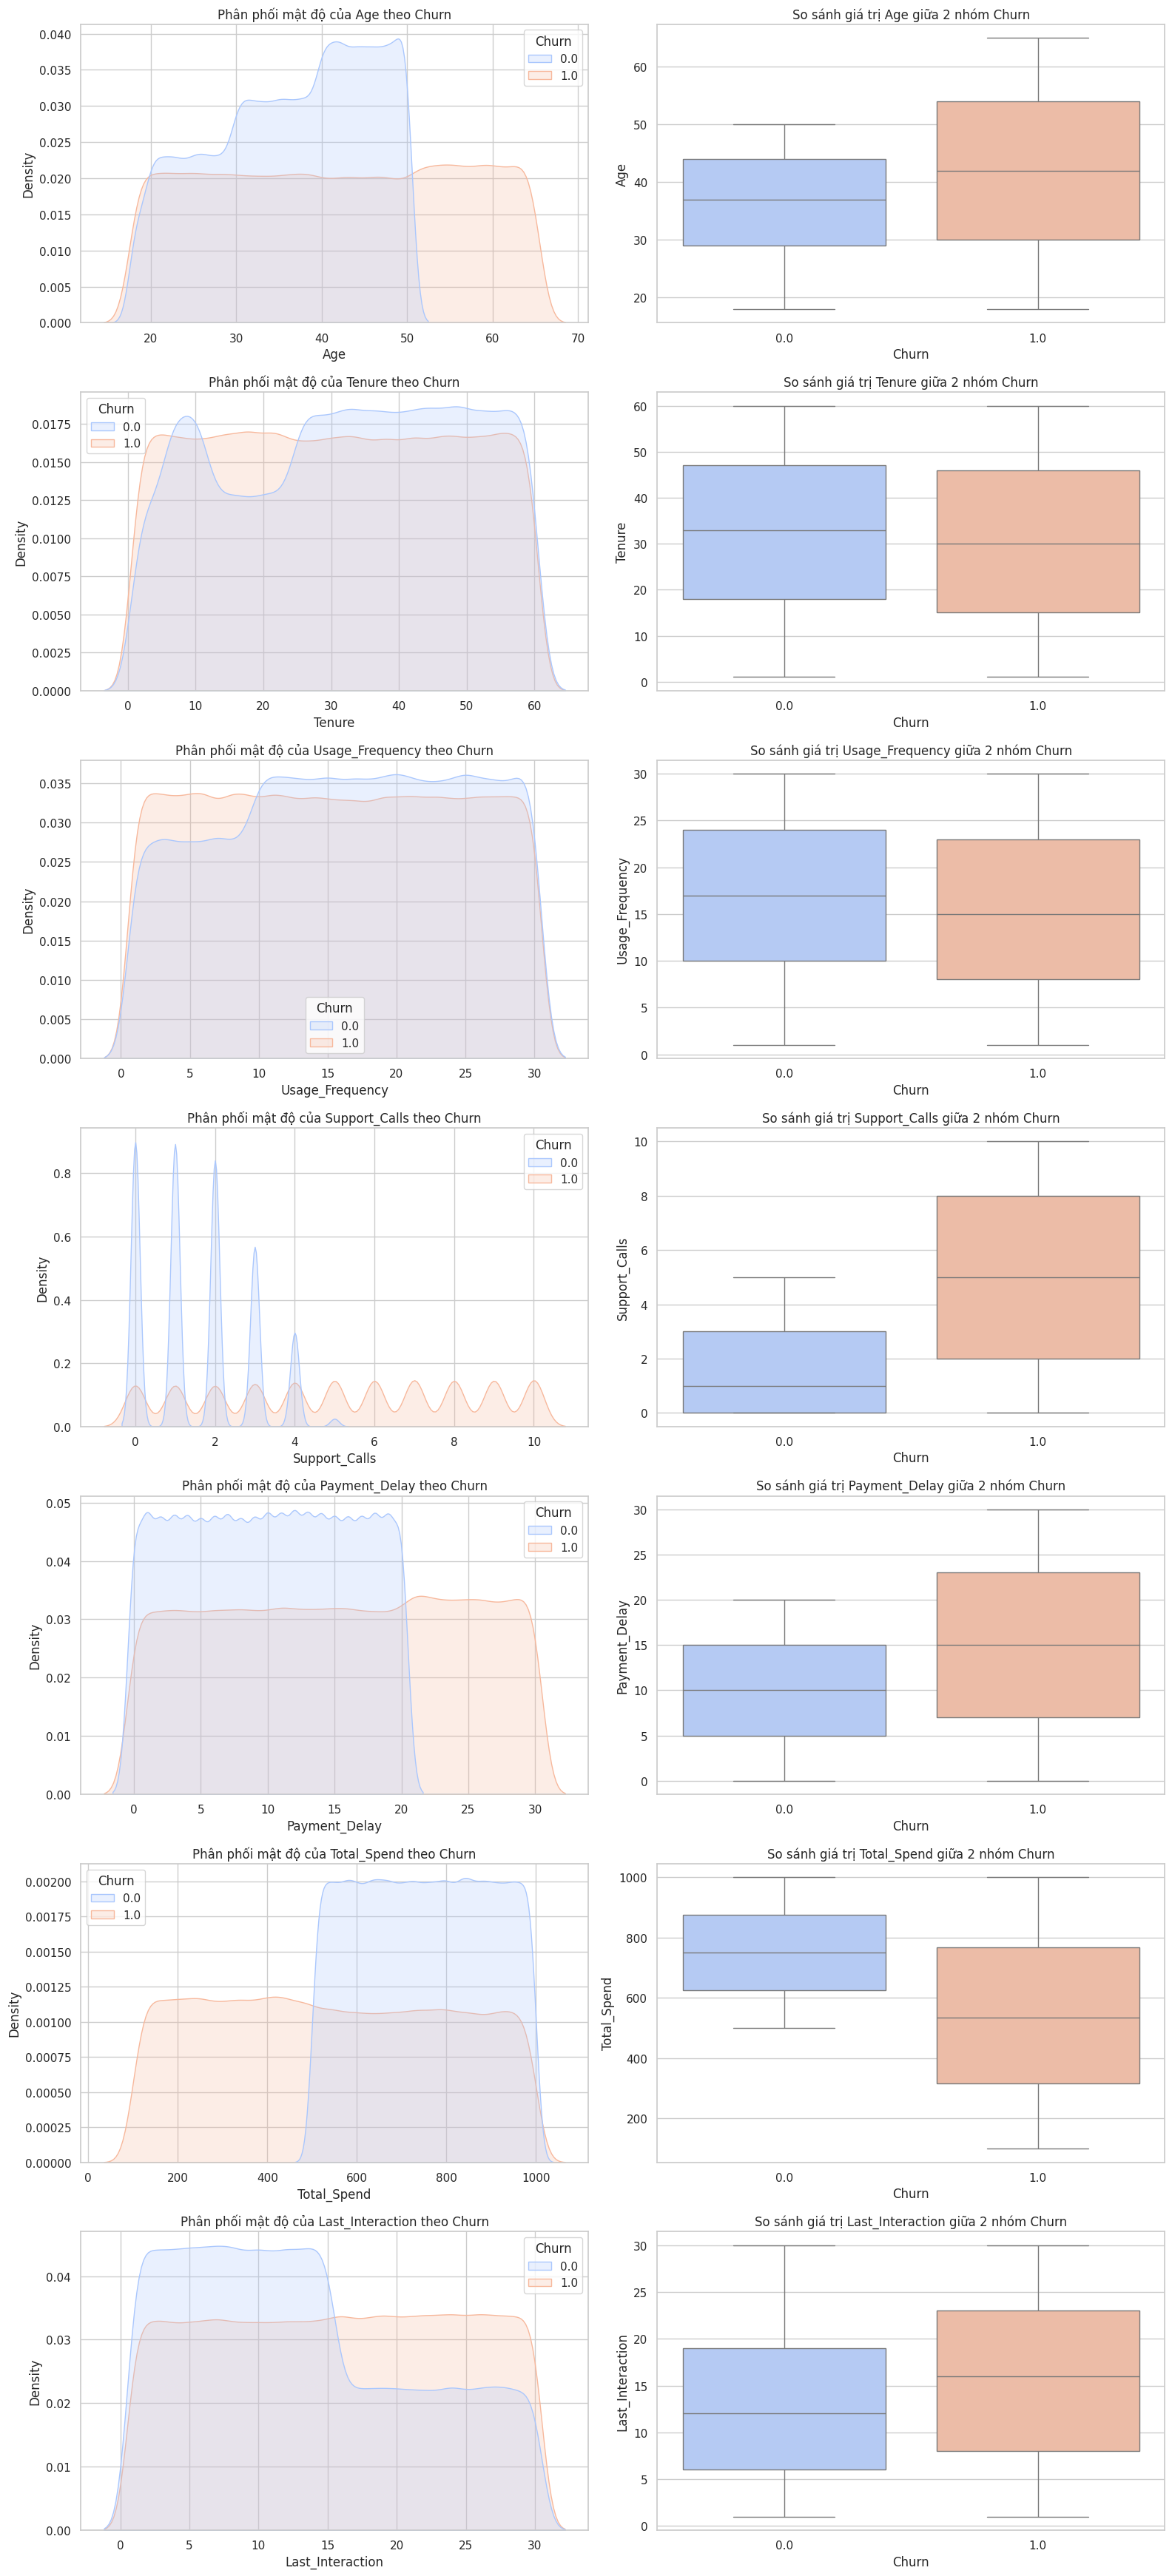

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Danh sách các biến định lượng (Numerical)
num_features = ['Age', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Delay', 'Total_Spend', 'Last_Interaction']

# Thiết lập layout cho biểu đồ (7 hàng, 2 cột: 1 bên KDE, 1 bên Boxplot)
fig, axes = plt.subplots(nrows=len(num_features), ncols=2, figsize=(16, 35))

for i, col in enumerate(num_features):
    # 1. Biểu đồ KDE Plot - So sánh hình dạng phân phối
    sns.kdeplot(data=df_train_cleaned, x=col, hue='Churn', fill=True,
                common_norm=False, palette='coolwarm', ax=axes[i, 0])
    axes[i, 0].set_title(f'Phân phối mật độ của {col} theo Churn')

    # 2. Biểu đồ Boxplot - So sánh các giá trị thống kê (Trung vị, Tứ phân vị)
    sns.boxplot(data=df_train_cleaned, x='Churn', y=col,
                palette='coolwarm', ax=axes[i, 1])
    axes[i, 1].set_title(f'So sánh giá trị {col} giữa 2 nhóm Churn')

plt.tight_layout()
plt.show()

### Quan hệ giữa Biến Định tính và Churn (Categorical vs Churn)

### Biểu đồ tương quan Gender (Giới tính) với Churn (Tỷ lệ rời bỏ)

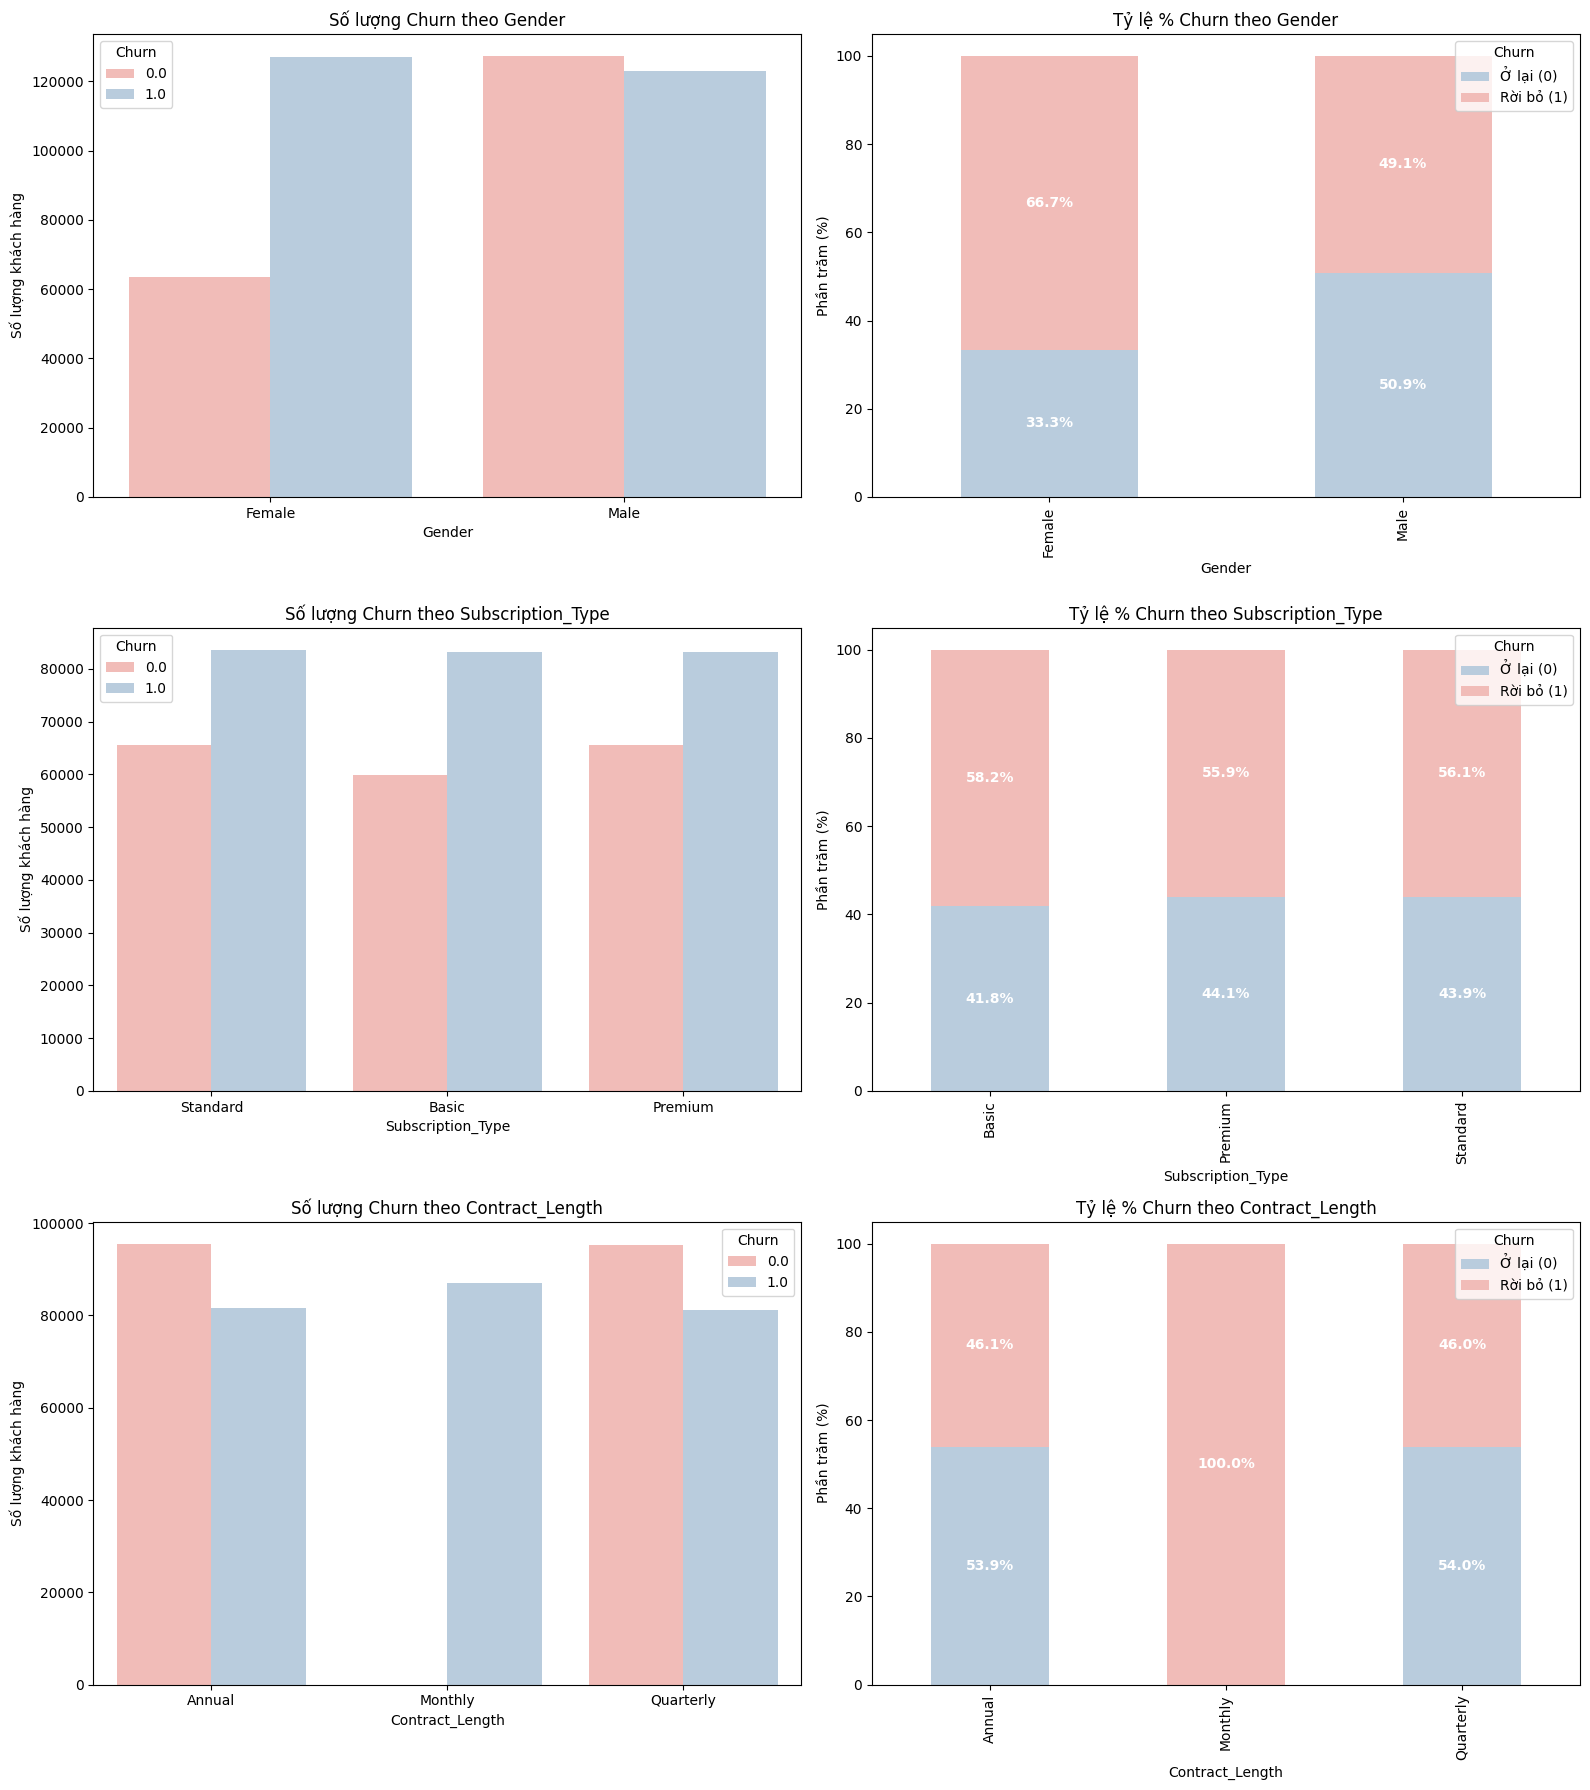

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Danh sách các biến định tính
cat_features = ['Gender', 'Subscription_Type', 'Contract_Length']

# Thiết lập layout: mỗi biến 1 hàng, 2 cột (Cột 1: Số lượng, Cột 2: Tỷ lệ %)
fig, axes = plt.subplots(nrows=len(cat_features), ncols=2, figsize=(16, 18))

for i, col in enumerate(cat_features):
    # 1. Biểu đồ Countplot (Số lượng tuyệt đối)
    sns.countplot(data=df_train_cleaned, x=col, hue='Churn', palette='Pastel1', ax=axes[i, 0])
    axes[i, 0].set_title(f'Số lượng Churn theo {col}')
    axes[i, 0].set_ylabel('Số lượng khách hàng')

    # 2. Biểu đồ Stacked Bar Chart (Tỷ lệ phần trăm %)
    # Tính toán bảng chéo tỷ lệ
    prop_df = pd.crosstab(df_train_cleaned[col], df_train_cleaned['Churn'], normalize='index') * 100
    prop_df.plot(kind='bar', stacked=True, color=['#B9CCDD', '#F1BCB8'], ax=axes[i, 1])

    axes[i, 1].set_title(f'Tỷ lệ % Churn theo {col}')
    axes[i, 1].set_ylabel('Phần trăm (%)')
    axes[i, 1].legend(title='Churn', labels=['Ở lại (0)', 'Rời bỏ (1)'], loc='upper right')

    # Thêm nhãn % lên biểu đồ stacked bar
    for p in axes[i, 1].patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if height > 0: # Chỉ hiện nhãn nếu phần trăm > 0
            axes[i, 1].annotate(f'{height:.1f}%', (x + width/2, y + height/2), ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()

### Ma trận tương quan (Correlation Matrix)

Heatmap chỉ có các thuộc tính có kiểu số thực. Các thuộc tính dạng chuỗi (Gender, Usage Frequency, Contract Length) không thể hiện được nên sẽ vẽ riêng.

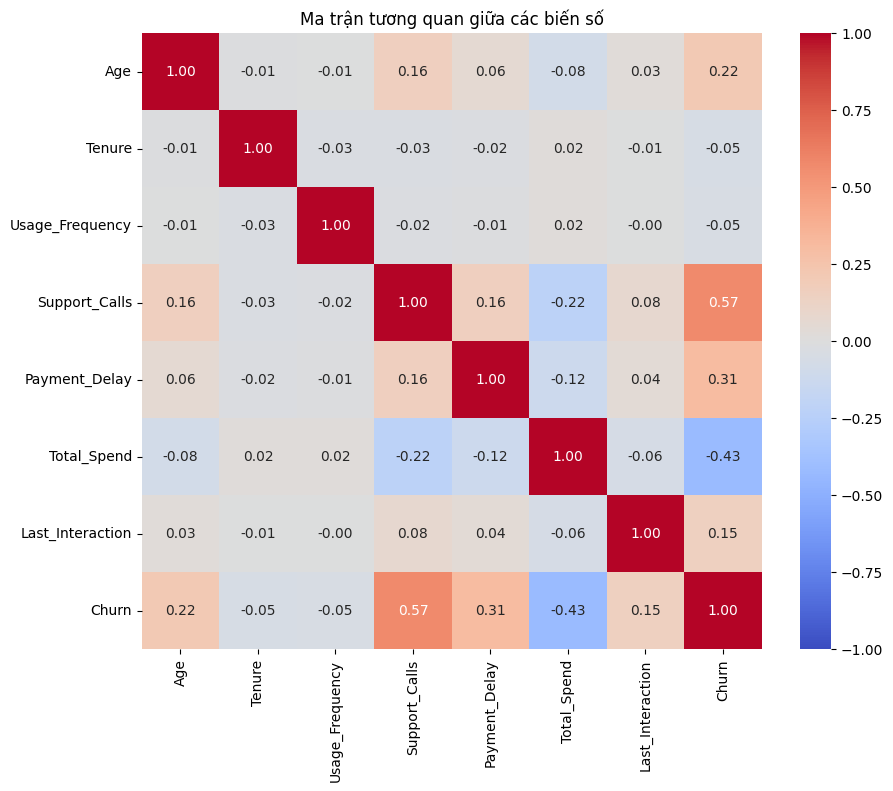

In [ ]:
plt.figure(figsize=(10, 8))

# Chỉ lấy các cột số để tính tương quan
numeric_df = df_train_cleaned.select_dtypes(include=['float64'])
corr_matrix = numeric_df.corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

=> Không có cặp biến nào đa cộng tuyến

=> Giữ nguyên tất cả



---



# PREPROCESSING - TIỀN XỬ LÝ DỮ LIỆU

## Encoding

### One-hot Encoding

Vì Logistics Regression chỉ chấp nhận One-hot Encoding và One-hot Encoding cũng không ảnh hưởng đến Random Forest, XGBoost.

=> Thực hiện One-Hot Encoding cho bộ dữ liệu để đảm bảo tương thích với cả 5 mô hình (Logistic Regression, KNN, SVM, Random Forest, XGBoost).

=> Sử dụng One-hot encoding with drop-first

In [ ]:
# 1. Xác định các cột định tính (Categorical) cần One-Hot
# Dựa trên dữ liệu của bạn: Gender, Subscription_Type, Contract_Length
categorical_cols = ['Gender', 'Subscription_Type', 'Contract_Length']

# 2. Thực hiện One-Hot Encoding cho tập TRAIN
# Tham số drop_first=True cực kỳ quan trọng cho Logistic Regression để tránh đa cộng tuyến
df_train_encoded = pd.get_dummies(df_train_cleaned, columns=categorical_cols, drop_first=True, dtype=int)

# 3. Thực hiện One-Hot Encoding cho tập TEST
df_test_encoded = pd.get_dummies(df_test_cleaned, columns=categorical_cols, drop_first=True, dtype=int)

# 4. Đồng bộ hóa các cột giữa tập Train và tập Test
# Đảm bảo tập Test có số lượng và thứ tự cột giống hệt tập Train
# (Trường hợp tập Test thiếu một giá trị nào đó so với Train, nó sẽ tự thêm cột và điền giá trị 0)
df_test_encoded = df_test_encoded.reindex(columns=df_train_encoded.columns, fill_value=0)

# 5. Kiểm tra kết quả
print("Danh sách các cột mới sau khi Encoding:")
print(df_train_encoded.columns.tolist())

# Hiển thị 5 dòng đầu để kiểm tra
print("\nDữ liệu sau khi mã hóa (5 dòng đầu):")
display(df_train_encoded.head())

Danh sách các cột mới sau khi Encoding:
['Age', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Delay', 'Total_Spend', 'Last_Interaction', 'Churn', 'Gender_Male', 'Subscription_Type_Premium', 'Subscription_Type_Standard', 'Contract_Length_Monthly', 'Contract_Length_Quarterly']

Dữ liệu sau khi mã hóa (5 dòng đầu):


,Age,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Total_Spend,Last_Interaction,Churn,Gender_Male,Subscription_Type_Premium,Subscription_Type_Standard,Contract_Length_Monthly,Contract_Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0,0,1,0,0
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,0,0,0,1,0
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,0,0,0,0,1
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,1,0,1,1,0
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,1,0,0,1,0


## Đa cộng tuyến

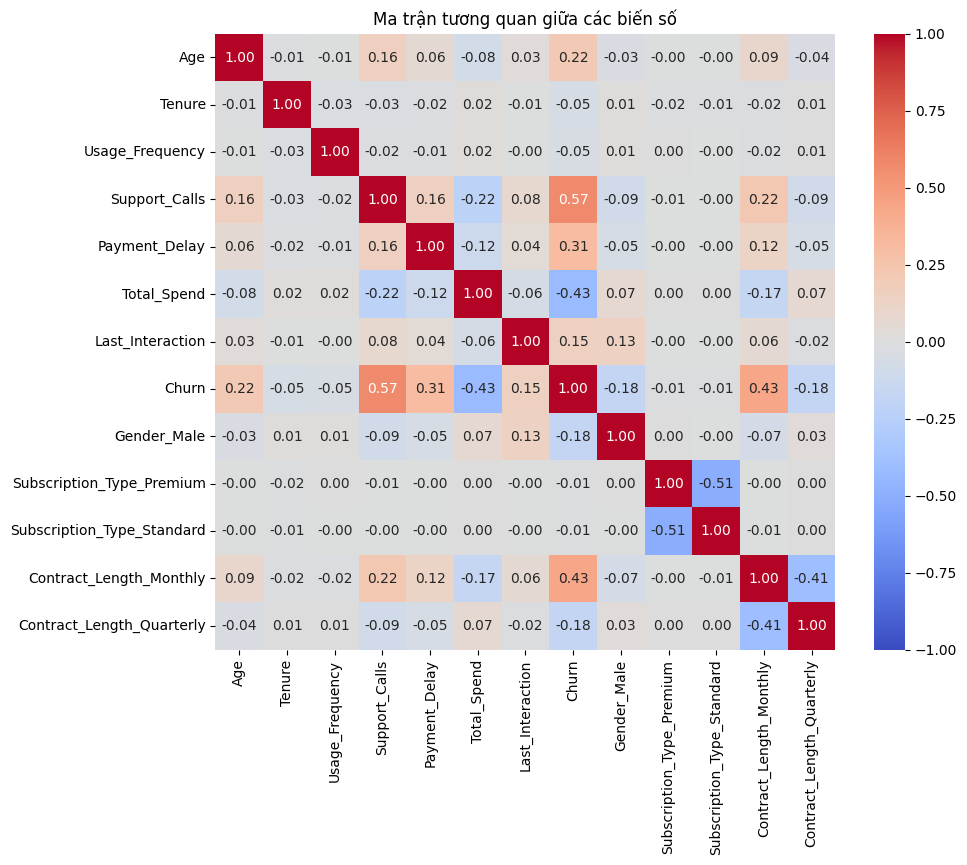

In [ ]:
plt.figure(figsize=(10, 8))

corr_matrix = df_train_encoded.corr()

# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

Kết quả ma trận tương quan cho thấy sự không hài lòng về dịch vụ (thể hiện qua số cuộc gọi hỗ trợ - 0.57) và loại hợp đồng ngắn hạn (Monthly - 0.43) là hai yếu tố hàng đầu thúc đẩy khách hàng rời bỏ dịch vụ. Ngược lại, mức chi tiêu cao (Total Spend - -0.43) cho thấy sự cam kết và hài lòng nhất định của khách hàng với dịch vụ hiện tại.

Các biến độc lập không xảy ra hiện tượng đa cộng tuyến nghiêm trọng, tạo điều kiện thuận lợi cho việc huấn luyện các mô hình phân loại.

## Scaling

Scaling cần thiết để đưa các biến số về cùng một phạm vi giá trị, đảm bảo các biến có số liệu lớn không lấn át các biến có số liệu nhỏ khi mô hình tính toán.

In [ ]:
# Chỉ định các cột số cần Scale (không scale các cột 0/1 của One-Hot)
num_features = ['Age', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Delay', 'Total_Spend', 'Last_Interaction']

# Tạo bản sao mới để không làm ảnh hưởng đến df_train_encoded
df_train_scaled = df_train_encoded.copy()
df_test_scaled = df_test_encoded.copy()

scaler = StandardScaler()

# Áp dụng scaling lên bản sao mới
df_train_scaled[num_features] = scaler.fit_transform(df_train_scaled[num_features])
df_test_scaled[num_features] = scaler.transform(df_test_scaled[num_features])

# Hiển thị 5 dòng đầu để kiểm tra
print("\nDữ liệu sau khi scaling (5 dòng đầu):")
display(df_train_encoded.head())



Dữ liệu sau khi scaling (5 dòng đầu):


,Age,Tenure,Usage_Frequency,Support_Calls,Payment_Delay,Total_Spend,Last_Interaction,Churn,Gender_Male,Subscription_Type_Premium,Subscription_Type_Standard,Contract_Length_Monthly,Contract_Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0,0,1,0,0
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,0,0,0,1,0
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1.0,0,0,0,0,1
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1.0,1,0,1,1,0
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1.0,1,0,0,1,0




---



# MÔ HÌNH

## Chia tập dữ liệu - Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Xác định Features (X) và Target (y) từ tập training đã chuẩn hóa
X = df_train_scaled.drop(columns=['Churn'])
y = df_train_scaled['Churn']

# 2. Chia dữ liệu theo tỷ lệ 80% Train - 20% Validation
# stratify=y: Đảm bảo tỷ lệ người rời bỏ (Churn) ở 2 tập mới bằng hệt tập gốc (56.71%)
# random_state=42: Cố định kết quả để mỗi lần chạy code đều ra kết quả giống nhau
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Chuẩn bị tập Test cuối cùng (từ file testing-master.csv)
X_test_final = df_test_scaled.drop(columns=['Churn'])
y_test_final = df_test_scaled['Churn']

# 4. Kiểm tra kích thước và tỷ lệ Churn
print("--- KÍCH THƯỚC DỮ LIỆU ---")
print(f"Tập Huấn luyện (Train):      {X_train.shape[0]} dòng")
print(f"Tập Kiểm chứng (Validation): {X_val.shape[0]} dòng")
print(f"Tập Kiểm thử cuối (Test):    {X_test_final.shape[0]} dòng")

print("\n--- TỶ LỆ CHURN (NHÃN 1) ---")
print(f"Tỷ lệ trong Train:      {y_train.mean():.2%}")
print(f"Tỷ lệ trong Validation: {y_val.mean():.2%}")
print(f"Tỷ lệ trong Test Final: {y_test_final.mean():.2%}")

--- KÍCH THƯỚC DỮ LIỆU ---
Tập Huấn luyện (Train):      352665 dòng
Tập Kiểm chứng (Validation): 88167 dòng
Tập Kiểm thử cuối (Test):    64374 dòng

--- TỶ LỆ CHURN (NHÃN 1) ---
Tỷ lệ trong Train:      56.71%
Tỷ lệ trong Validation: 56.71%
Tỷ lệ trong Test Final: 47.37%


## Logistic Regression (Hồi quy Logistic)

### Huấn luyện mô hình

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, recall_score

# 1. Khởi tạo mô hình
lr = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

# 2. Định nghĩa các tổ hợp tham số muốn thử nghiệm
param_grid = {
    'C': [0.01, 0.1, 1, 10],                   # Thử các mức điều chuẩn
    'class_weight': [{0: 1, 1: 1},             # Mặc định
                     {0: 1, 1: 1.5},           # Ưu tiên nhãn 1 hơn chút
                     {0: 1, 1: 2},             # Ưu tiên nhãn 1 gấp đôi
                     'balanced']               # Tự động cân bằng
}

# 3. Sử dụng Recall làm tiêu chuẩn để chọn mô hình tốt nhất (để giảm False Negative)
scorer = make_scorer(recall_score)

grid_search = GridSearchCV(estimator=lr, param_grid=param_grid, scoring=scorer, cv=5)
grid_search.fit(X_train, y_train)

# 4. In ra bộ tham số tối ưu nhất
print("Bộ tham số tốt nhất để tối ưu Recall:", grid_search.best_params_)

# 5. Sử dụng mô hình tốt nhất để dự đoán
best_log_reg = grid_search.best_estimator_
y_val_pred = best_log_reg.predict(X_val)

Bộ tham số tốt nhất để tối ưu Recall: {'C': 0.01, 'class_weight': {0: 1, 1: 2}}


In [ ]:


# 3. In kết quả cuối cùng của Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix
print("--- KẾT QUẢ LOGISTIC REGRESSION SAU TỐI ƯU ---")
print(classification_report(y_val, y_val_pred))

--- KẾT QUẢ LOGISTIC REGRESSION SAU TỐI ƯU ---
              precision    recall  f1-score   support

         0.0       0.89      0.82      0.85     38167
         1.0       0.87      0.93      0.90     50000

    accuracy                           0.88     88167
   macro avg       0.88      0.87      0.87     88167
weighted avg       0.88      0.88      0.88     88167



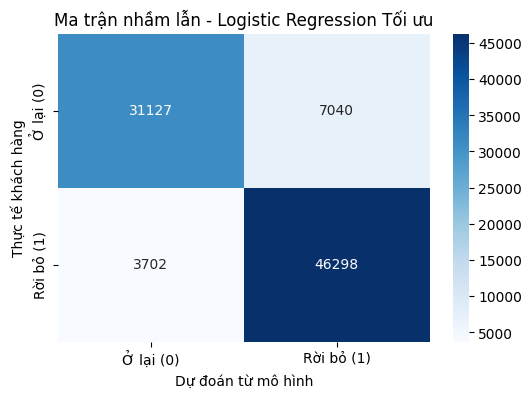

Số lượng khách hàng rời bỏ bị bỏ sót (False Negative): 3702
Tỷ lệ nhận diện đúng khách hàng rời bỏ (Recall): 92.60%


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ở lại (0)', 'Rời bỏ (1)'],
            yticklabels=['Ở lại (0)', 'Rời bỏ (1)'])
plt.xlabel('Dự đoán từ mô hình')
plt.ylabel('Thực tế khách hàng')
plt.title('Ma trận nhầm lẫn - Logistic Regression Tối ưu')
plt.show()

# Tính toán số lượng bỏ sót (False Negative)
fn = cm[1, 0]
print(f"Số lượng khách hàng rời bỏ bị bỏ sót (False Negative): {fn}")
print(f"Tỷ lệ nhận diện đúng khách hàng rời bỏ (Recall): {cm[1,1]/(cm[1,0]+cm[1,1]):.2%}")

Đang huấn luyện mô hình...
KẾT QUẢ TRÊN TẬP VALIDATION:
Độ chính xác (Accuracy): 0.8934

Báo cáo chi tiết:
              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88     38167
         1.0       0.92      0.89      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.89      0.89     88167
weighted avg       0.89      0.89      0.89     88167



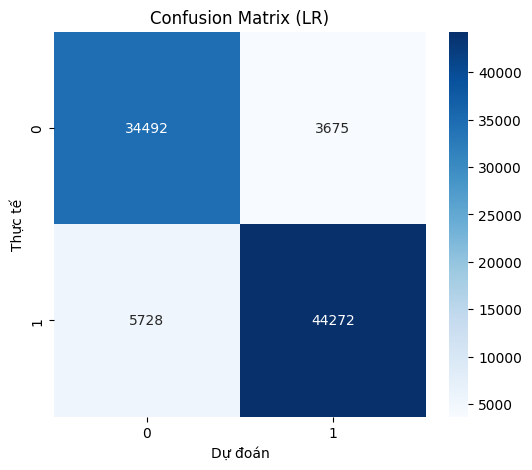

In [ ]:

# 1. Khởi tạo mô hình
# random_state=42 để kết quả không đổi mỗi lần chạy
# max_iter=1000 để đảm bảo mô hình chạy đủ lâu để tìm ra đáp án (nếu dữ liệu phức tạp)
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# 2. Huấn luyện mô hình (Học trên tập Train)
print("Đang huấn luyện mô hình...")
lr_model.fit(X_train, y_train)

# 3. Dự đoán thử trên tập Validation (Để xem học hành thế nào)
y_pred_val_lr = lr_model.predict(X_val)

# 4. Đánh giá kết quả
print("=" * 30)
print("KẾT QUẢ TRÊN TẬP VALIDATION:")
print(f"Độ chính xác (Accuracy): {accuracy_score(y_val, y_pred_val_lr):.4f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_val, y_pred_val_lr))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_val, y_pred_val_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (LR)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()


### Tìm tham số tối ưu C bằng Optuna

### Dự báo và đánh giá


KẾT QUẢ LOGISTIC REGRESSION (ĐÃ TỐI ƯU)
Accuracy: 0.8946

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.93      0.88     38167
         1.0       0.94      0.87      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.90      0.89     88167
weighted avg       0.90      0.89      0.89     88167



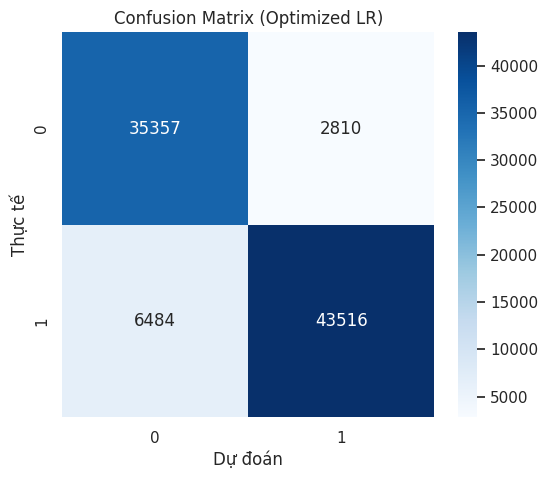

In [ ]:
# 4. Dự đoán trên tập Validation
y_pred_final = final_lr_model.predict(X_val_ohe)

# 5. Đánh giá kết quả cuối cùng
print("\n" + "="*40)
print("KẾT QUẢ LOGISTIC REGRESSION (ĐÃ TỐI ƯU)")
print("="*40)
print(f"Accuracy: {accuracy_score(y_val_ohe, y_pred_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_val_ohe, y_pred_final))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_val_ohe, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Optimized LR)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()



---



## KNN

### Huấn luyện mô hình

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. Khởi tạo mô hình với các tham số cố định
knn_fixed = KNeighborsClassifier(metric='euclidean', weights='distance')

# 2. Định nghĩa dải k cần tìm
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]}

# 3. Sử dụng GridSearchCV với mục tiêu tối ưu Recall
knn_k_search = GridSearchCV(
    estimator=knn_fixed,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

# 4. Huấn luyện trên tập mẫu nhỏ
knn_k_search.fit(X_train, y_train)

# 5. Kết quả k tốt nhất
best_k = knn_k_search.best_params_['n_neighbors']
print(f"Giá trị k tối ưu nhất cho Recall là: {best_k}")

Giá trị k tối ưu nhất cho Recall là: 3


In [ ]:
# 1. Khởi tạo mô hình KNN
# n_neighbors=5: Chọn 5 người hàng xóm gần nhất để bỏ phiếu
# n_jobs=-1: Sử dụng tất cả các nhân CPU để chạy nhanh hơn (Cực kỳ cần thiết với dữ liệu lớn)
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

print(f"Đang huấn luyện KNN trên tập Train kích thước {X_train.shape}...")
start_time = time.time()

# 2. Huấn luyện (Fit)
knn_model.fit(X_train, y_train)

print(f"-> Thời gian Fit: {time.time() - start_time:.2f} giây")



Đang huấn luyện KNN trên tập Train kích thước (352665, 10)...
-> Thời gian Fit: 1.68 giây


### Dự đoán và đánh giá

Đang dự đoán trên tập Validation...
-> Thời gian Predict: 45.23 giây

--- KẾT QUẢ CỦA KNN ---
Độ chính xác (Accuracy): 0.9594

Báo cáo chi tiết:
              precision    recall  f1-score   support

         0.0       0.92      1.00      0.96     38167
         1.0       1.00      0.93      0.96     50000

    accuracy                           0.96     88167
   macro avg       0.96      0.96      0.96     88167
weighted avg       0.96      0.96      0.96     88167



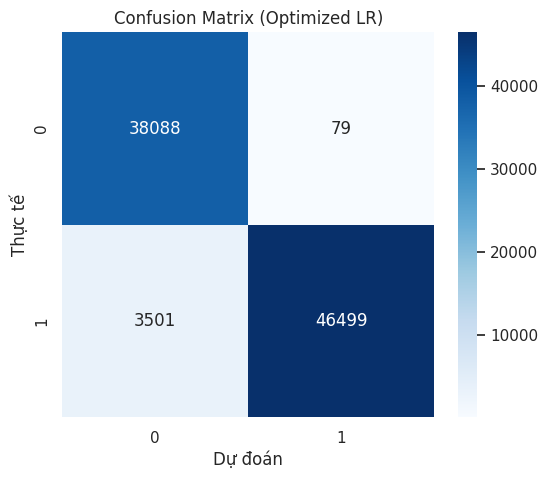

In [ ]:
# 3. Dự đoán (Predict)
print("Đang dự đoán trên tập Validation...")
start_time = time.time()

y_pred_knn = knn_model.predict(X_val)

print(f"-> Thời gian Predict: {time.time() - start_time:.2f} giây")

# 4. Đánh giá kết quả
print("\n--- KẾT QUẢ CỦA KNN ---")
print(f"Độ chính xác (Accuracy): {accuracy_score(y_val, y_pred_knn):.4f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_val, y_pred_knn))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_val, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Optimized LR)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()



---



## SVM

### LinearSVC

**Huấn luyện mô hình**

In [ ]:

# ==========================================================
# CẤU HÌNH LINEAR SVC CHO DỮ LIỆU LỚN
# ==========================================================

# 1. Khởi tạo mô hình
# dual=False: Cấu hình BẮT BUỘC khi số lượng mẫu (440k) > số lượng thuộc tính (Features)
# class_weight='balanced': Tự động xử lý mất cân bằng dữ liệu (giúp bắt Churn tốt hơn)
# max_iter=2000: Tăng số vòng lặp để đảm bảo mô hình hội tụ (tìm ra đáp án)
svm_model = LinearSVC(
    random_state=42,
    dual=False,            # Quan trọng nhất để chạy nhanh
    class_weight='balanced',
    max_iter=2000
)

print(f"🚀 Đang huấn luyện LINEAR SVC trên toàn bộ {X_train.shape[0]} dòng dữ liệu...")
start_time = time.time()

# 2. Huấn luyện (Fit)
svm_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"✅ Hoàn thành sau: {train_time:.2f} giây")



🚀 Đang huấn luyện LINEAR SVC trên toàn bộ 352665 dòng dữ liệu...
✅ Hoàn thành sau: 1.26 giây


**Dự đoán và đánh giá**

Đang dự đoán trên tập Validation...

KẾT QUẢ LINEAR SVC (CHẠY FULL DATA)
Độ chính xác (Accuracy): 0.8710

Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86     38167
         1.0       0.92      0.85      0.88     50000

    accuracy                           0.87     88167
   macro avg       0.87      0.87      0.87     88167
weighted avg       0.88      0.87      0.87     88167



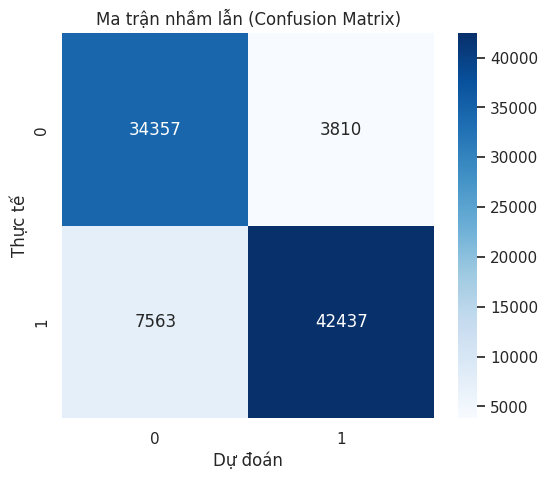

In [ ]:
# 3. Dự đoán (Predict)
print("Đang dự đoán trên tập Validation...")
y_pred_svm = svm_model.predict(X_val)

# 4. Đánh giá kết quả
print("\n" + "="*40)
print("KẾT QUẢ LINEAR SVC (CHẠY FULL DATA)")
print("="*40)

# Độ chính xác tổng
acc = accuracy_score(y_val, y_pred_svm)
print(f"Độ chính xác (Accuracy): {acc:.4f}")

# Báo cáo chi tiết (Precision, Recall, F1)
print("\nClassification Report:")
print(classification_report(y_val, y_pred_svm))

# Ma trận nhầm lẫn
cm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

### SVM trên 20000 dòng

**Huấn luyện mô hình**

In [ ]:

# 1. LẤY MẪU (SAMPLING)
# Chỉ lấy 20.000 dòng đầu tiên để train thử
sample_size = 20000
X_train_small = X_train[:sample_size]
y_train_small = y_train[:sample_size]

print(f"⚠️ Đang huấn luyện Kernel SVM (RBF) trên mẫu nhỏ: {sample_size} dòng...")

# 2. Khởi tạo mô hình SVC
# kernel='rbf': Mặc định, giúp vẽ đường cong phi tuyến tính
svm_rbf = SVC(
    kernel='rbf',
    random_state=42,
    class_weight='balanced',
    probability=False # Để False cho nhanh, nếu cần predict_proba thì để True (sẽ rất chậm)
)

start_time = time.time()

# 3. Huấn luyện (Trên tập nhỏ)
svm_rbf.fit(X_train_small, y_train_small)

print(f"-> Thời gian Train: {time.time() - start_time:.2f} giây")

print(f"Đã huấn luyện Kernel SVM (RBF) xong!")

⚠️ Đang huấn luyện Kernel SVM (RBF) trên mẫu nhỏ: 20000 dòng...
-> Thời gian Train: 4.23 giây
Đã huấn luyện Kernel SVM (RBF) xong!


**Dự báo và đánh giá**

Đang dự đoán...

KẾT QUẢ KERNEL SVM (RBF)
Độ chính xác: 0.9684
              precision    recall  f1-score   support

         0.0       0.94      1.00      0.96     38167
         1.0       1.00      0.95      0.97     50000

    accuracy                           0.97     88167
   macro avg       0.97      0.97      0.97     88167
weighted avg       0.97      0.97      0.97     88167



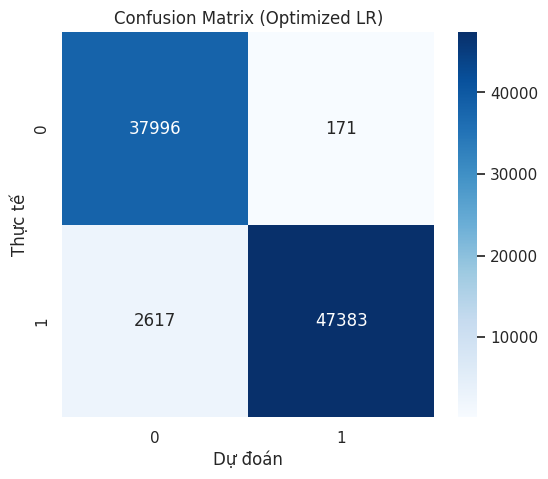

In [ ]:

# 4. Dự đoán (Có thể dự đoán trên toàn bộ tập Val)
print("Đang dự đoán...")
y_pred_rbf = svm_rbf.predict(X_val)

# 5. Đánh giá
print("\n" + "="*40)
print("KẾT QUẢ KERNEL SVM (RBF)")
print("="*40)
print(f"Độ chính xác: {accuracy_score(y_val, y_pred_rbf):.4f}")
print(classification_report(y_val, y_pred_rbf))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_val, y_pred_rbf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Optimized LR)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()



---



## Random Forest

### Huấn luyện mô hình

In [ ]:

# 1. Khởi tạo mô hình
# n_estimators=100: Số lượng cây (càng nhiều càng chính xác nhưng chậm hơn)
# max_depth=20: Giới hạn độ sâu của cây (giúp không bị học vẹt/overfitting và giảm RAM)
# n_jobs=-1: Sử dụng tất cả nhân CPU để chạy nhanh nhất có thể
# class_weight='balanced': Tự động điều chỉnh trọng số nếu số người Rời bỏ quá ít so với Ở lại
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=20,     # Có thể tăng lên hoặc bỏ đi nếu muốn cây mọc tự do
    min_samples_leaf=5, # Mỗi lá phải có ít nhất 5 mẫu -> Giảm nhiễu
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print(f"Đang huấn luyện Random Forest trên {X_train.shape[0]} dòng dữ liệu...")
start_time = time.time()

# 2. Huấn luyện
rf_model.fit(X_train, y_train)

print(f"-> Thời gian Train: {time.time() - start_time:.2f} giây")



Đang huấn luyện Random Forest trên 352665 dòng dữ liệu...
-> Thời gian Train: 59.44 giây


### Dự đoán và đánh giá

Đang dự đoán...

KẾT QUẢ RANDOM FOREST
Độ chính xác (Accuracy): 0.9997

Báo cáo chi tiết:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



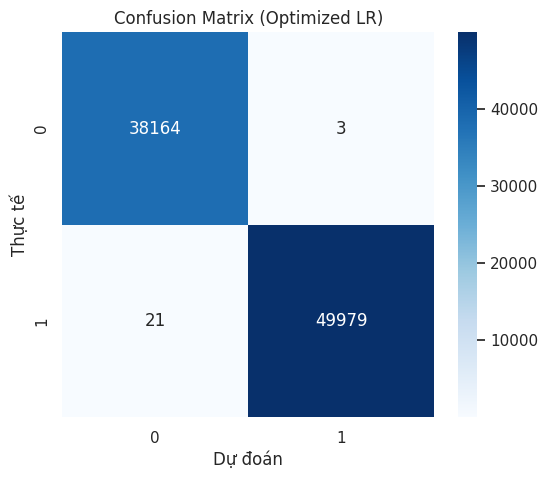

In [ ]:
# 3. Dự đoán trên tập Validate
print("Đang dự đoán...")
y_pred_rf = rf_model.predict(X_val)

# 4. Đánh giá kết quả
print("\n" + "="*40)
print("KẾT QUẢ RANDOM FOREST")
print("="*40)
print(f"Độ chính xác (Accuracy): {accuracy_score(y_val, y_pred_rf):.4f}")
print("\nBáo cáo chi tiết:")
print(classification_report(y_val, y_pred_rf))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_val, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Optimized LR)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()





---



## XGBoost

### Huấn luyện mô hình

Mô hình có early_stopping_rounds=20

In [ ]:

# 1. Tính toán tỷ lệ cân bằng
count_class_0 = len(y_train[y_train == 0])
count_class_1 = len(y_train[y_train == 1])
weight_ratio = count_class_0 / count_class_1

# 2. Khởi tạo mô hình
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=weight_ratio,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    early_stopping_rounds=20,
    eval_metric='logloss'
)

print(f"\nĐang huấn luyện XGBoost trên {X_train.shape[0]} dòng...")
start_time = time.time()

# 3. Huấn luyện

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)

print(f"\n-> Thời gian Train: {time.time() - start_time:.2f} giây")




Đang huấn luyện XGBoost trên 352665 dòng...
[0]	validation_0-logloss:0.64795	validation_1-logloss:0.64802
[1]	validation_0-logloss:0.60708	validation_1-logloss:0.60722
[2]	validation_0-logloss:0.56995	validation_1-logloss:0.57015
[3]	validation_0-logloss:0.53608	validation_1-logloss:0.53633
[4]	validation_0-logloss:0.50509	validation_1-logloss:0.50540
[5]	validation_0-logloss:0.47666	validation_1-logloss:0.47702
[6]	validation_0-logloss:0.45049	validation_1-logloss:0.45089
[7]	validation_0-logloss:0.42636	validation_1-logloss:0.42681
[8]	validation_0-logloss:0.40405	validation_1-logloss:0.40455
[9]	validation_0-logloss:0.38340	validation_1-logloss:0.38394
[10]	validation_0-logloss:0.36425	validation_1-logloss:0.36484
[11]	validation_0-logloss:0.34647	validation_1-logloss:0.34710
[12]	validation_0-logloss:0.32992	validation_1-logloss:0.33059
[13]	validation_0-logloss:0.31452	validation_1-logloss:0.31522
[14]	validation_0-logloss:0.30016	validation_1-logloss:0.30090
[15]	validation_0-lo

### Dự đoán & Đánh giá

Đang dự đoán...

KẾT QUẢ XGBOOST
Độ chính xác: 0.9999
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



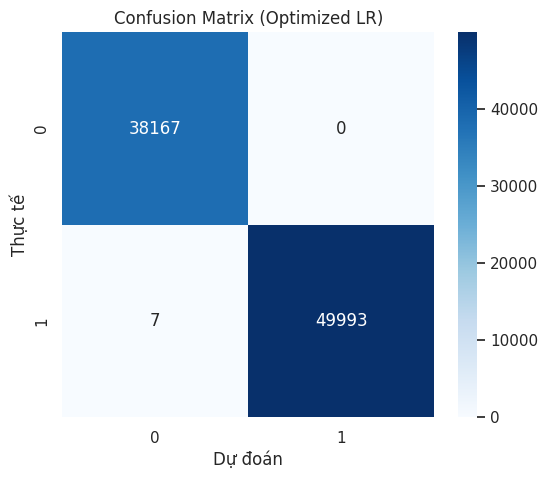

In [ ]:
# 4. Dự đoán & Đánh giá
print("Đang dự đoán...")

y_pred_xgb = xgb_model.predict(X_val)

print("\n" + "="*40)
print("KẾT QUẢ XGBOOST")
print("="*40)
print(f"Độ chính xác: {accuracy_score(y_val, y_pred_xgb):.4f}")
print(classification_report(y_val, y_pred_xgb))

# Vẽ ma trận nhầm lẫn
cm = confusion_matrix(y_val, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Optimized LR)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()





---



# KẾT QUẢ

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)
import pandas as pd

print ('=== BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH===')

def summarize_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    }

results = []

results.append(
    summarize_model(
        "Logistic Regression",
        y_val_ohe,
        y_pred_val_lr
    )
)

results.append(
    summarize_model(
        "KNN",
        y_val,
        y_pred_knn
    )
)

results.append(
    summarize_model(
        "Linear SVC",
        y_val,
        y_pred_svm
    )
)

results.append(
    summarize_model(
        "SVM (RBF)",
        y_val,
        y_pred_rbf
    )
)

results.append(
    summarize_model(
        "Random Forest",
        y_val,
        y_pred_rf
    )
)

results.append(
    summarize_model(
        "XGBoost",
        y_val,
        y_pred_xgb
    )
)

results_df = pd.DataFrame(results)
results_df


=== BẢNG TỔNG HỢP KẾT QUẢ CÁC MÔ HÌNH===


,Model,Accuracy,Precision,Recall,F1-score,TP,FP,FN,TN
0,Logistic Regression,0.893350,0.923353,0.88544,0.903999,44272,3675,5728,34492
1,KNN,0.959395,0.998304,0.92998,0.962932,46499,79,3501,38088
2,Linear SVC,0.871006,0.917616,0.84874,0.881835,42437,3810,7563,34357
3,SVM (RBF),0.968378,0.996404,0.94766,0.971421,47383,171,2617,37996
4,Random Forest,0.999728,0.999940,0.99958,0.999760,49979,3,21,38164
5,XGBoost,0.999921,1.000000,0.99986,0.999930,49993,0,7,38167




---



# CÁC YẾU TỐ ẢNH HƯỞNG

## Logistics Regression

**Bảng tổng hợp các yếu tố ảnh hưởng đến Churn**

In [ ]:

# 1) Lấy hệ số (coef) + intercept
coefs = lr_model.coef_.ravel()          # shape (n_features,)
intercept = float(lr_model.intercept_[0])

# 2) Tạo bảng hệ số
impact_df = pd.DataFrame({
    "Feature": X_train_ohe.columns,
    "Coefficient": coefs
})

# 3) Thêm độ ảnh hưởng tuyệt đối + hướng tác động
impact_df["Abs_Coefficient"] = impact_df["Coefficient"].abs()
impact_df["Effect"] = np.where(impact_df["Coefficient"] > 0, "Tăng churn", "Giảm churn")

# 4) Odds Ratio (exp(coef)) để diễn giải kinh doanh
impact_df["Odds_Ratio"] = np.exp(impact_df["Coefficient"])

# 5) Sắp xếp theo độ ảnh hưởng
impact_df = impact_df.sort_values("Abs_Coefficient", ascending=False)

print("Intercept:", intercept)
display(impact_df.head(15))


Intercept: 1.3607507960429028


,Feature,Coefficient,Abs_Coefficient,Effect,Odds_Ratio
10,Contract_Length_Monthly,10.072241,10.072241,Tăng churn,23676.568735
3,Support_Calls,2.301302,2.301302,Tăng churn,9.987177
5,Total_Spend,-1.457461,1.457461,Giảm churn,0.232827
7,Gender_Male,-1.149121,1.149121,Giảm churn,0.316915
4,Payment_Delay,0.924446,0.924446,Tăng churn,2.520472
6,Last_Interaction,0.524768,0.524768,Tăng churn,1.690067
0,Age,0.444960,0.444960,Tăng churn,1.560428
1,Tenure,-0.136173,0.136173,Giảm churn,0.872692
2,Usage_Frequency,-0.128796,0.128796,Giảm churn,0.879153
8,Subscription_Type_Premium,-0.121553,0.121553,Giảm churn,0.885544


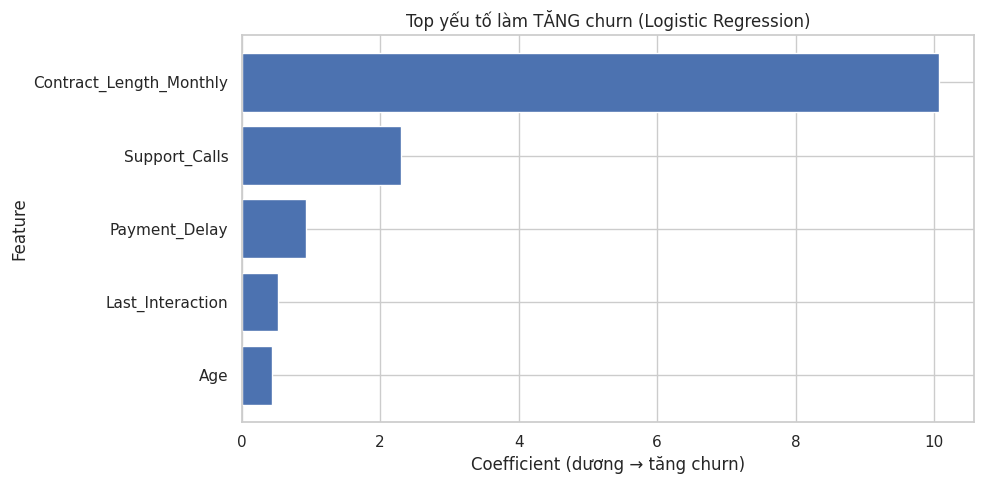

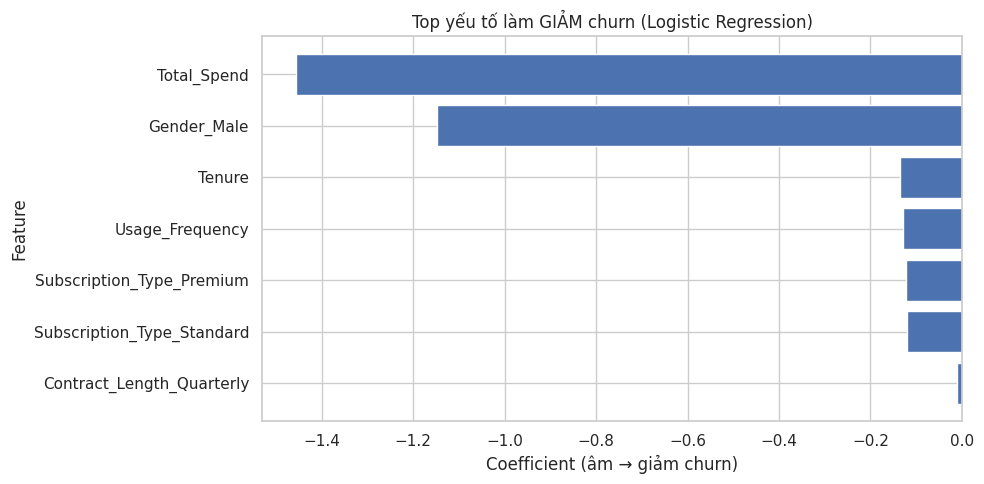

In [ ]:
# ===== 1) Tạo impact_df từ Logistic Regression =====
impact_df["Abs_Coefficient"] = impact_df["Coefficient"].abs()
impact_df["Odds_Ratio"] = np.exp(impact_df["Coefficient"])
impact_df["Effect"] = np.where(impact_df["Coefficient"] > 0, "Tăng churn", "Giảm churn")

# ===== 2) Fix tên nhóm biến (Base_Feature) cho đúng =====
# Ưu tiên match theo prefix chuẩn trước, không tách bừa theo "_"
KNOWN_PREFIXES = [
    "Contract_Length",
    "Subscription_Type",
    "Support_Calls",
    "Usage_Frequency",
    "Payment_Delay",
    "Total_Spend",
    "Last_Interaction",
    "Gender",
    "Tenure",
    "Age"
]

def get_base_feature(col: str) -> str:
    for p in KNOWN_PREFIXES:
        if col.startswith(p):
            return p
    # fallback: nếu không match, lấy phần trước dấu _ cuối cùng (an toàn hơn split đầu)
    if "_" in col:
        return col.rsplit("_", 1)[0]
    return col

impact_df["Base_Feature"] = impact_df["Feature"].apply(get_base_feature)

# ===== 3) Vẽ 2 biểu đồ: Top tăng churn và Top giảm churn =====
top_k = 10

top_increase = impact_df[impact_df["Coefficient"] > 0].sort_values("Abs_Coefficient", ascending=False).head(top_k)
top_decrease = impact_df[impact_df["Coefficient"] < 0].sort_values("Abs_Coefficient", ascending=False).head(top_k)

# --- Plot 1: Tăng churn ---
plt.figure(figsize=(10, 5))
plt.barh(top_increase["Feature"][::-1], top_increase["Coefficient"][::-1])
plt.title(f"Top yếu tố làm TĂNG churn (Logistic Regression)")
plt.xlabel("Coefficient (dương → tăng churn)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# --- Plot 2: Giảm churn ---
plt.figure(figsize=(10, 5))
plt.barh(top_decrease["Feature"][::-1], top_decrease["Coefficient"][::-1])
plt.title(f"Top yếu tố làm GIẢM churn (Logistic Regression)")
plt.xlabel("Coefficient (âm → giảm churn)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()




## Random Forest

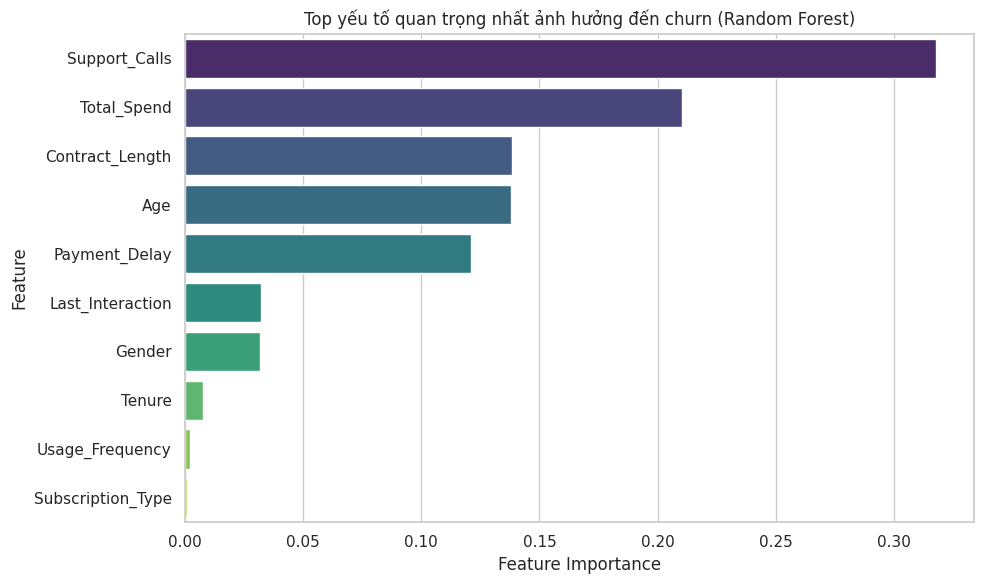


TOP yếu tố quan trọng nhất:


,Feature,Importance
4,Support_Calls,0.317929
8,Total_Spend,0.210497
7,Contract_Length,0.138225
0,Age,0.137771
5,Payment_Delay,0.121233
9,Last_Interaction,0.032137
1,Gender,0.031634
2,Tenure,0.007487
3,Usage_Frequency,0.002128
6,Subscription_Type,0.000959


In [ ]:

# Lấy feature importance
importances = rf_model.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': X_train.columns,   # ĐẢM BẢO đúng dữ liệu RF dùng
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feature_imp_df

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    palette='viridis'
)
plt.title('Top yếu tố quan trọng nhất ảnh hưởng đến churn (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(f"\nTOP yếu tố quan trọng nhất:")
display(top_features)


Chỉ biết được biến nào ảnh hưởng, không biết ảnh hưởng như thế nào (tăng/giảm)

## XGBoost

**Các yếu tố ảnh hưởng**

Mô hình dùng biến nào nhiều nhất để chia

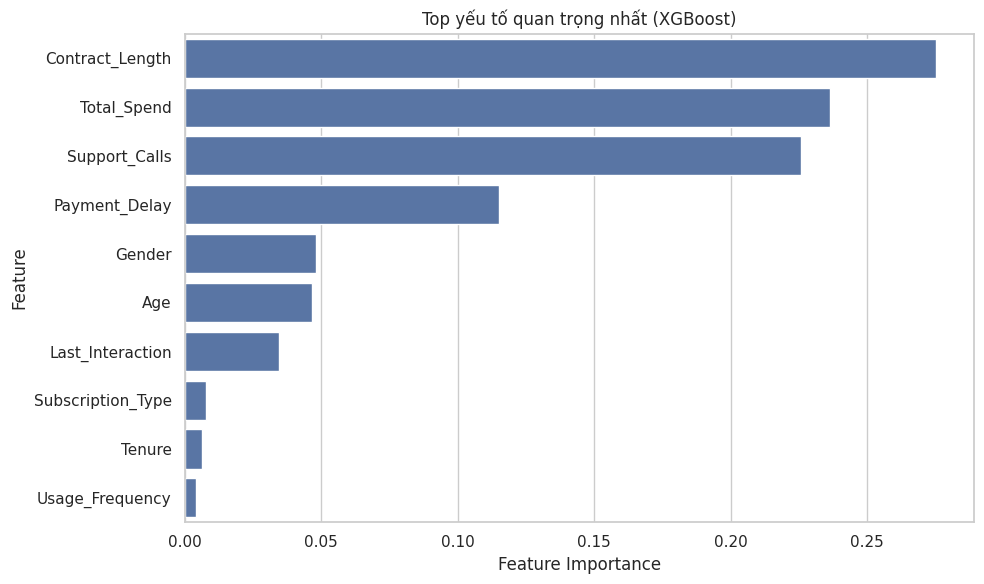

Top yếu tố quan trọng nhất (XGBoost)


,Feature,Importance
7,Contract_Length,0.275354
8,Total_Spend,0.236393
4,Support_Calls,0.225711
5,Payment_Delay,0.115222
1,Gender,0.048204
0,Age,0.046439
9,Last_Interaction,0.034516
6,Subscription_Type,0.007904
2,Tenure,0.006357
3,Usage_Frequency,0.003900


In [ ]:
importances = xgb_model.feature_importances_

feature_imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

top_k = 10
top_features = feature_imp_df.head(top_k)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=top_features)
plt.title("Top yếu tố quan trọng nhất (XGBoost)")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top yếu tố quan trọng nhất (XGBoost)")
display(top_features)


**SHAP**

Sử dụng SHAP để tìm ra các yếu tố ảnh hưởng như thế nào (tăng/giảm churn)

Biến nào ảnh hưởng mạnh nhất đến dự đoán

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

# Dùng tập validation để giải thích
shap_values = explainer.shap_values(X_val)


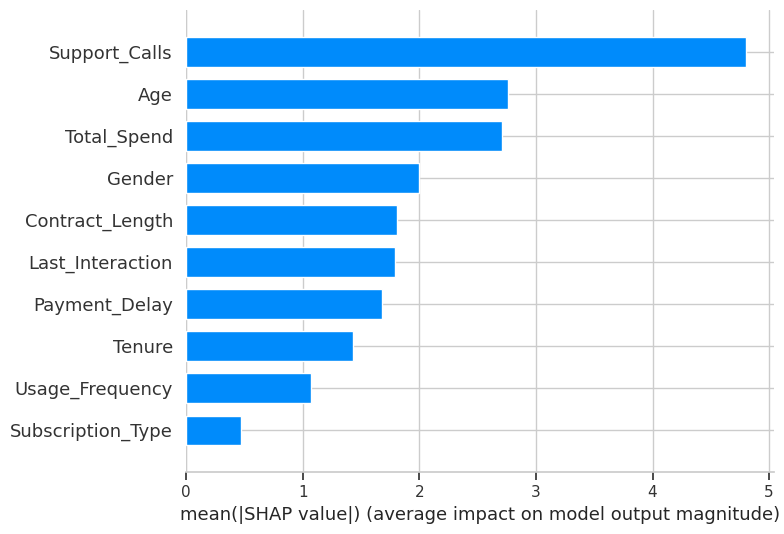

In [ ]:
print("TOP các yếu tố ảnh hưởng (XGBoost)")
shap.summary_plot(shap_values, X_val, plot_type="bar")


Các yếu tố ảnh hưởng như thế nào? (XGBoost)


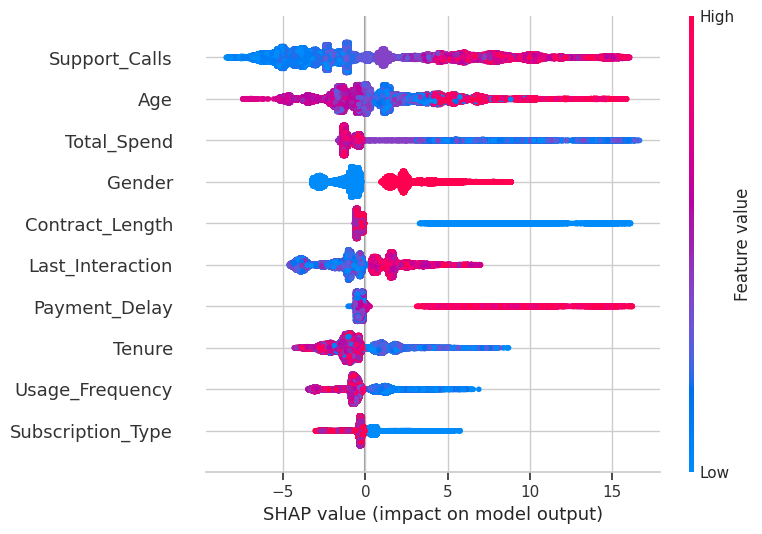

In [ ]:
print("Các yếu tố ảnh hưởng như thế nào? (XGBoost)")
shap.summary_plot(shap_values, X_val)


=>
- SHAP phản ánh hành vi thực

- Feature Importance phản ánh logic rẽ nhánh



---



# DỰ ĐOÁN TRÊN TẬP TEST

**Gộp train và val lại để huấn luyện lại mô hình**

In [ ]:
# Ghép train + val (giữ cùng cấu trúc cột)
X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)

# Check cột khớp giữa full-train và test
assert list(X_full.columns) == list(X_test.columns), "❌ Cột X_full và X_test không khớp!"
print("✅ Columns khớp giữa X_full và X_test")


X_full shape: (440832, 10)
y_full shape: (440832,)
✅ Columns khớp giữa X_full và X_test


**Huấn luyện mô hình**

In [ ]:
print(f"🚀 Training FINAL XGBoost on full data: {X_full.shape[0]} rows ...")

xgb_model.fit(
    X_full, y_full,
    eval_set=[(X_full, y_full), (X_test, y_test)],
    verbose=True
)
print("✅ Done training final model!")



🚀 Training FINAL XGBoost on full data: 440832 rows ...
[0]	validation_0-logloss:0.64799	validation_1-logloss:0.69186
[1]	validation_0-logloss:0.60715	validation_1-logloss:0.69292
[2]	validation_0-logloss:0.57005	validation_1-logloss:0.69603
[3]	validation_0-logloss:0.53622	validation_1-logloss:0.70091
[4]	validation_0-logloss:0.50526	validation_1-logloss:0.70737
[5]	validation_0-logloss:0.47684	validation_1-logloss:0.71518
[6]	validation_0-logloss:0.45070	validation_1-logloss:0.72425
[7]	validation_0-logloss:0.42659	validation_1-logloss:0.73440
[8]	validation_0-logloss:0.40430	validation_1-logloss:0.74556
[9]	validation_0-logloss:0.38367	validation_1-logloss:0.75761
[10]	validation_0-logloss:0.36454	validation_1-logloss:0.77047
[11]	validation_0-logloss:0.34677	validation_1-logloss:0.78406
[12]	validation_0-logloss:0.33025	validation_1-logloss:0.79835
[13]	validation_0-logloss:0.31486	validation_1-logloss:0.81322
[14]	validation_0-logloss:0.30051	validation_1-logloss:0.82868
[15]	valid

**Dự đoán và đánh giá**


KẾT QUẢ TRÊN TẬP TEST (XGBOOST)
Accuracy : 0.5279
Precision: 0.5008
Recall   : 0.9974
F1-score : 0.6668

Classification report:
               precision    recall  f1-score   support

         0.0       0.98      0.11      0.19     33881
         1.0       0.50      1.00      0.67     30493

    accuracy                           0.53     64374
   macro avg       0.74      0.55      0.43     64374
weighted avg       0.75      0.53      0.42     64374


Confusion Matrix: TP=30413, FP=30311, FN=80, TN=3570


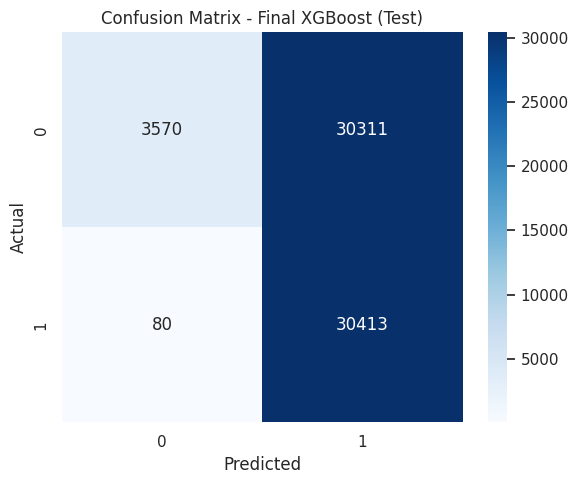

In [ ]:

y_test_pred = xgb_model.predict(X_test)

# Nếu bạn có y_test:
print("\n" + "="*40)
print("KẾT QUẢ TRÊN TẬP TEST (XGBOOST)")
print("="*40)

print(f"Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_test_pred):.4f}")

print("\nClassification report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Final XGBoost (Test)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()




---



# TẢI TỆP HTML

In [ ]:
!pip install -U nbconvert

In [ ]:
# Chuyển file sang html
!jupyter nbconvert --to html "/content/drive/MyDrive/UIT/PTDLKD/DOAN/NEW_DOAN_NHOM3.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/UIT/PTDLKD/DOAN/NEW_DOAN_NHOM3.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 23 image(s).
[NbConvertApp] Writing 2666396 bytes to /content/drive/MyDrive/UIT/PTDLKD/DOAN/NEW_DOAN_NHOM3.html


In [ ]:
# Tải file html về
from google.colab import files
files.download("/content/drive/MyDrive/UIT/PTDLKD/DOAN/NEW_DOAN_NHOM3.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>